# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

ID : 각 항목에 대한 고유 식별자  
Customer_ID : 개인을 식별하는 고유 식별자  
Month : 해당 연도의 월  
Name : 개인의 이름  
Age : 개인의 나이  
SSN : 개인의 사회 보장 번호 (Social Security Number)  
Occupation : 개인의 직업   
Annual_Income : 개인의 연간 소득  
Monthly_Inhand_Salary : 개인의 월별 기본 급여  
Num_Bank_Accounts : 개인이 보유한 은행 계좌의 수  
Num_Credit_Card : 개인이 보유한 신용카드의 수  
Interest_Rate : 신용카드의 이자율  
Num_of_Loan : 은행에서 받은 대출의 수  
Type_of_Loan : 개인이 받은 대출의 종류  
Delay_from_due_date : 평균적으로 납부 기한을 초과한 일수  
Num_of_Delayed_Payment : 개인이 지연한 평균 납부 횟수  
Changed_Credit_Limit : 신용카드 한도 변경 비율  
Num_Credit_Inquiries : 신용카드 조회 횟수  
Credit_Mix : 신용 혼합 유형의 분류  
Outstanding_Debt : 미지급 잔액 (USD 기준)  
Credit_Utilization_Ratio : 신용카드 이용 비율  
Credit_History_Age : 개인의 신용 이력 연수  
Payment_of_Min_Amount : 최소 금액만 지불했는지 여부  
Total_EMI_per_month : 월별 EMI(할부금) 납부 금액 (USD 기준)  
Amount_invested_monthly : 고객이 월별로 투자한 금액 (USD 기준)  
Payment_Behaviour : 고객의 납부 행태 (USD 기준)  
Monthly_Balance : 고객의 월별 잔액 (USD 기준)  

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

# 데이터 로드 및 확인

In [ ]:
import torch
import numpy as np

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
df = pd.read_csv(file_path)
df.head(3)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good


In [2]:
df['Customer_ID'].nunique()

12500

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

In [4]:
# == 시계열 적 부분 반영하기위해
# 데이터가 id = 12500, 각 8개월씩임.
# =========================
# 고객별 월별 시계열 요약 파생변수
# =========================

df = df.sort_values(['Customer_ID', 'Month']).reset_index(drop=True)

seq_cols = [
    'Outstanding_Debt',
    'Monthly_Balance',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly'
]

for col in seq_cols:

    # 이전달 값
    lag_col = df.groupby('Customer_ID')[col].shift(1)

    # 변화량
    df[f'{col}_diff1'] = df[col] - lag_col

    # 고객 평균 패턴
    df[f'{col}_mean_by_customer'] = (
        df.groupby('Customer_ID')[col].transform('mean')
    )

# diff 결측 처리
time_cols = []

for col in seq_cols:
    time_cols.extend([
        f'{col}_diff1',
        f'{col}_mean_by_customer'
    ])

df[time_cols] = df[time_cols].fillna(0)

In [5]:
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

### 고객별 월별 패턴 반영

본 데이터는 동일 고객이 여러 월에 걸쳐 반복 관측된 구조를 가진다. 따라서 각 행을 완전히 독립적인 관측치로만 처리할 경우 고객별 금융 상태의 변화 흐름을 충분히 반영하기 어렵다고 판단하였다.

이에 따라 Customer_ID와 Month를 기준으로 데이터를 정렬한 뒤, 주요 금융 변수에 대해 이전 월 값(lag), 전월 대비 변화량(diff), 고객별 평균 및 표준편차 변수를 생성하였다.

Customer_ID 자체는 식별자이므로 학습 변수로 사용하지 않고, 고객별 시계열 특성을 요약하는 기준으로만 활용하였다.

In [6]:
df.describe()
# Annual_Income : 7005 ~ 179987 / mean = 50505
# Monthly_Inhand_Salary : 303 ~ 15204 / mean = 4197.270835

# 이상치가 존재해보임. 허나, 금융데이터에서는 존재할 수 있는 데이터인 경우가 있어 확인 후 드랍 or 리스케일링 진행

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Delay_from_due_date_diff1,Delay_from_due_date_mean_by_customer,Num_of_Delayed_Payment_diff1,Num_of_Delayed_Payment_mean_by_customer,Credit_Utilization_Ratio_diff1,Credit_Utilization_Ratio_mean_by_customer,Total_EMI_per_month_diff1,Total_EMI_per_month_mean_by_customer,Amount_invested_monthly_diff1,Amount_invested_monthly_mean_by_customer
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000
mean,4.500000,33.316340,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,...,0.001880,21.081410,0.000540,13.31312,0.007164,32.285173,2.484421,107.699208,0.0,55.101315
std,2.291299,10.764812,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,...,2.233877,14.720582,1.567094,6.13808,6.628110,2.060484,56.212706,119.472009,0.0,39.006932
min,1.000000,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,...,-10.000000,0.000000,-6.000000,0.00000,-21.694155,25.476634,-1727.662487,0.000000,0.0,0.000000
25%,2.750000,24.000000,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,...,0.000000,9.875000,0.000000,9.00000,-4.191624,30.854492,0.000000,30.306321,0.0,27.959111
50%,4.500000,33.000000,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,...,0.000000,17.875000,0.000000,13.75000,0.000000,32.241830,0.000000,68.086281,0.0,45.156550
75%,6.250000,42.000000,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,...,0.000000,28.000000,0.000000,18.25000,4.230786,33.600168,0.000000,150.918680,0.0,71.295797
max,8.000000,56.000000,179987.280000,15204.633330,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,...,10.000000,62.000000,6.000000,25.00000,25.099654,42.395301,1775.000000,1515.158987,0.0,434.191089


# EDA

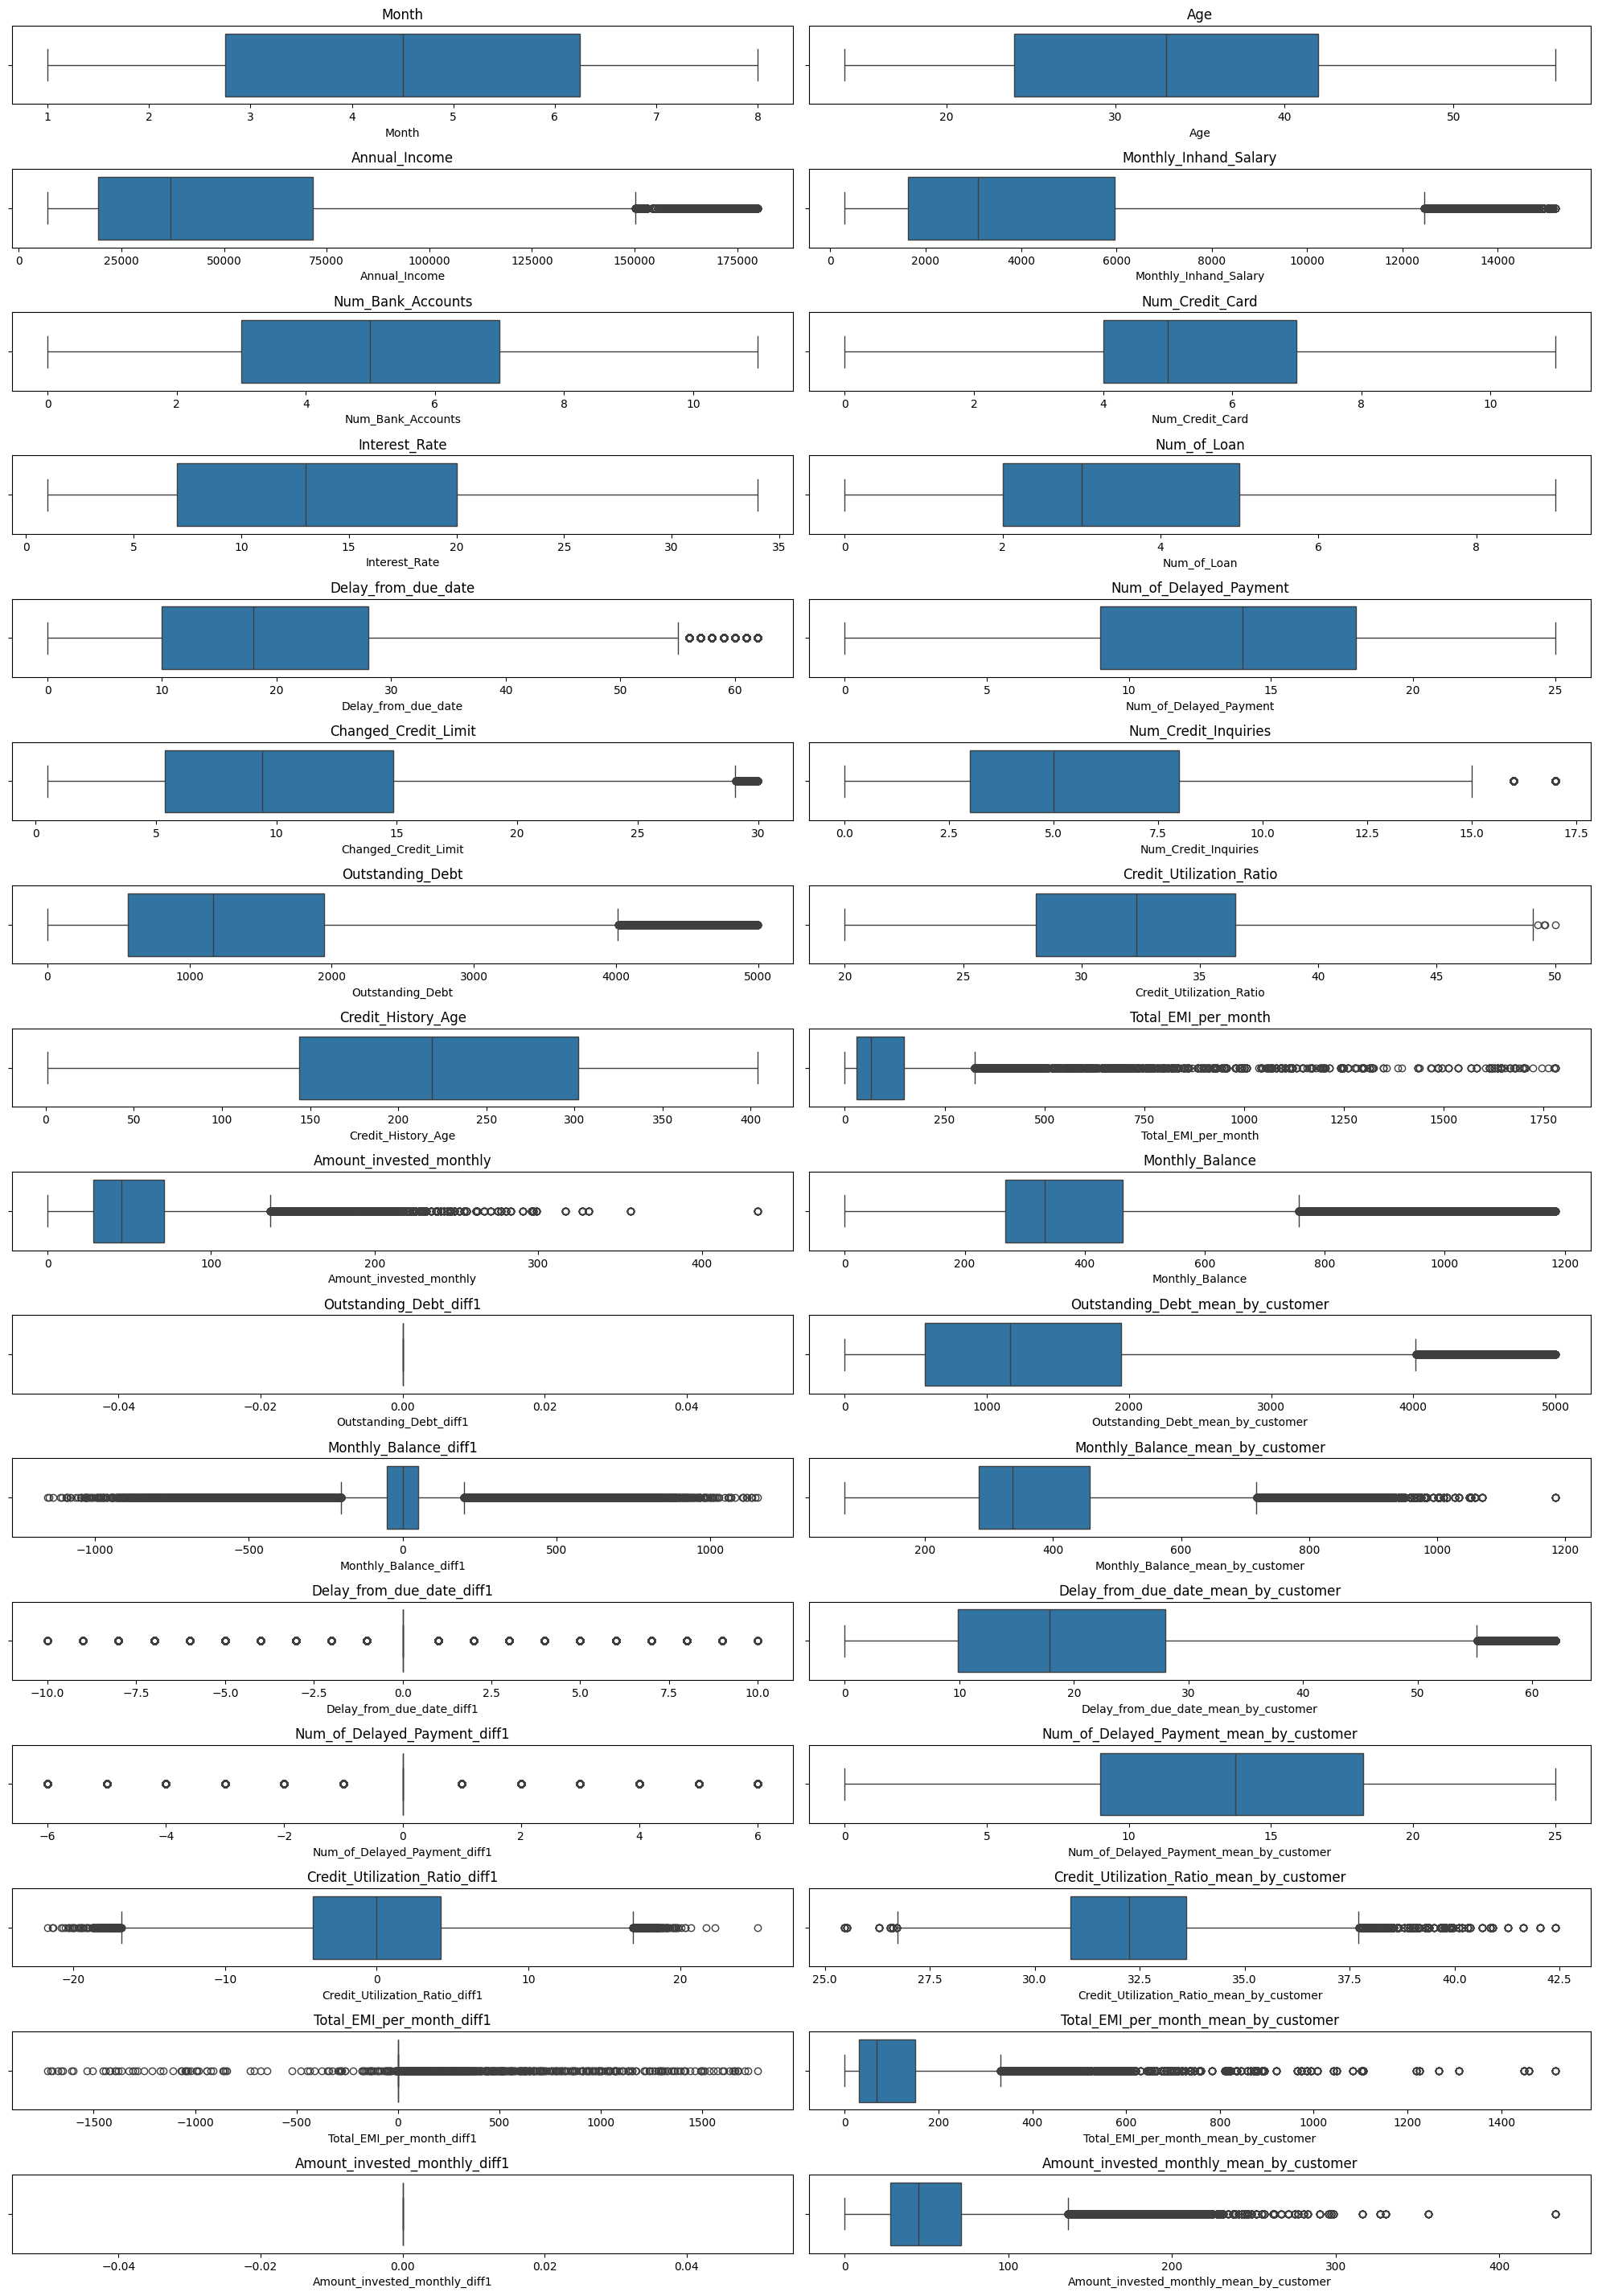

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 컬럼 추출
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 박스플롯 시각화
plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols):

    plt.subplot(len(numeric_cols)//2 + 1, 2, i+1)

    sns.boxplot(x=df[col])

    plt.title(f'{col}')

plt.tight_layout()
plt.show()

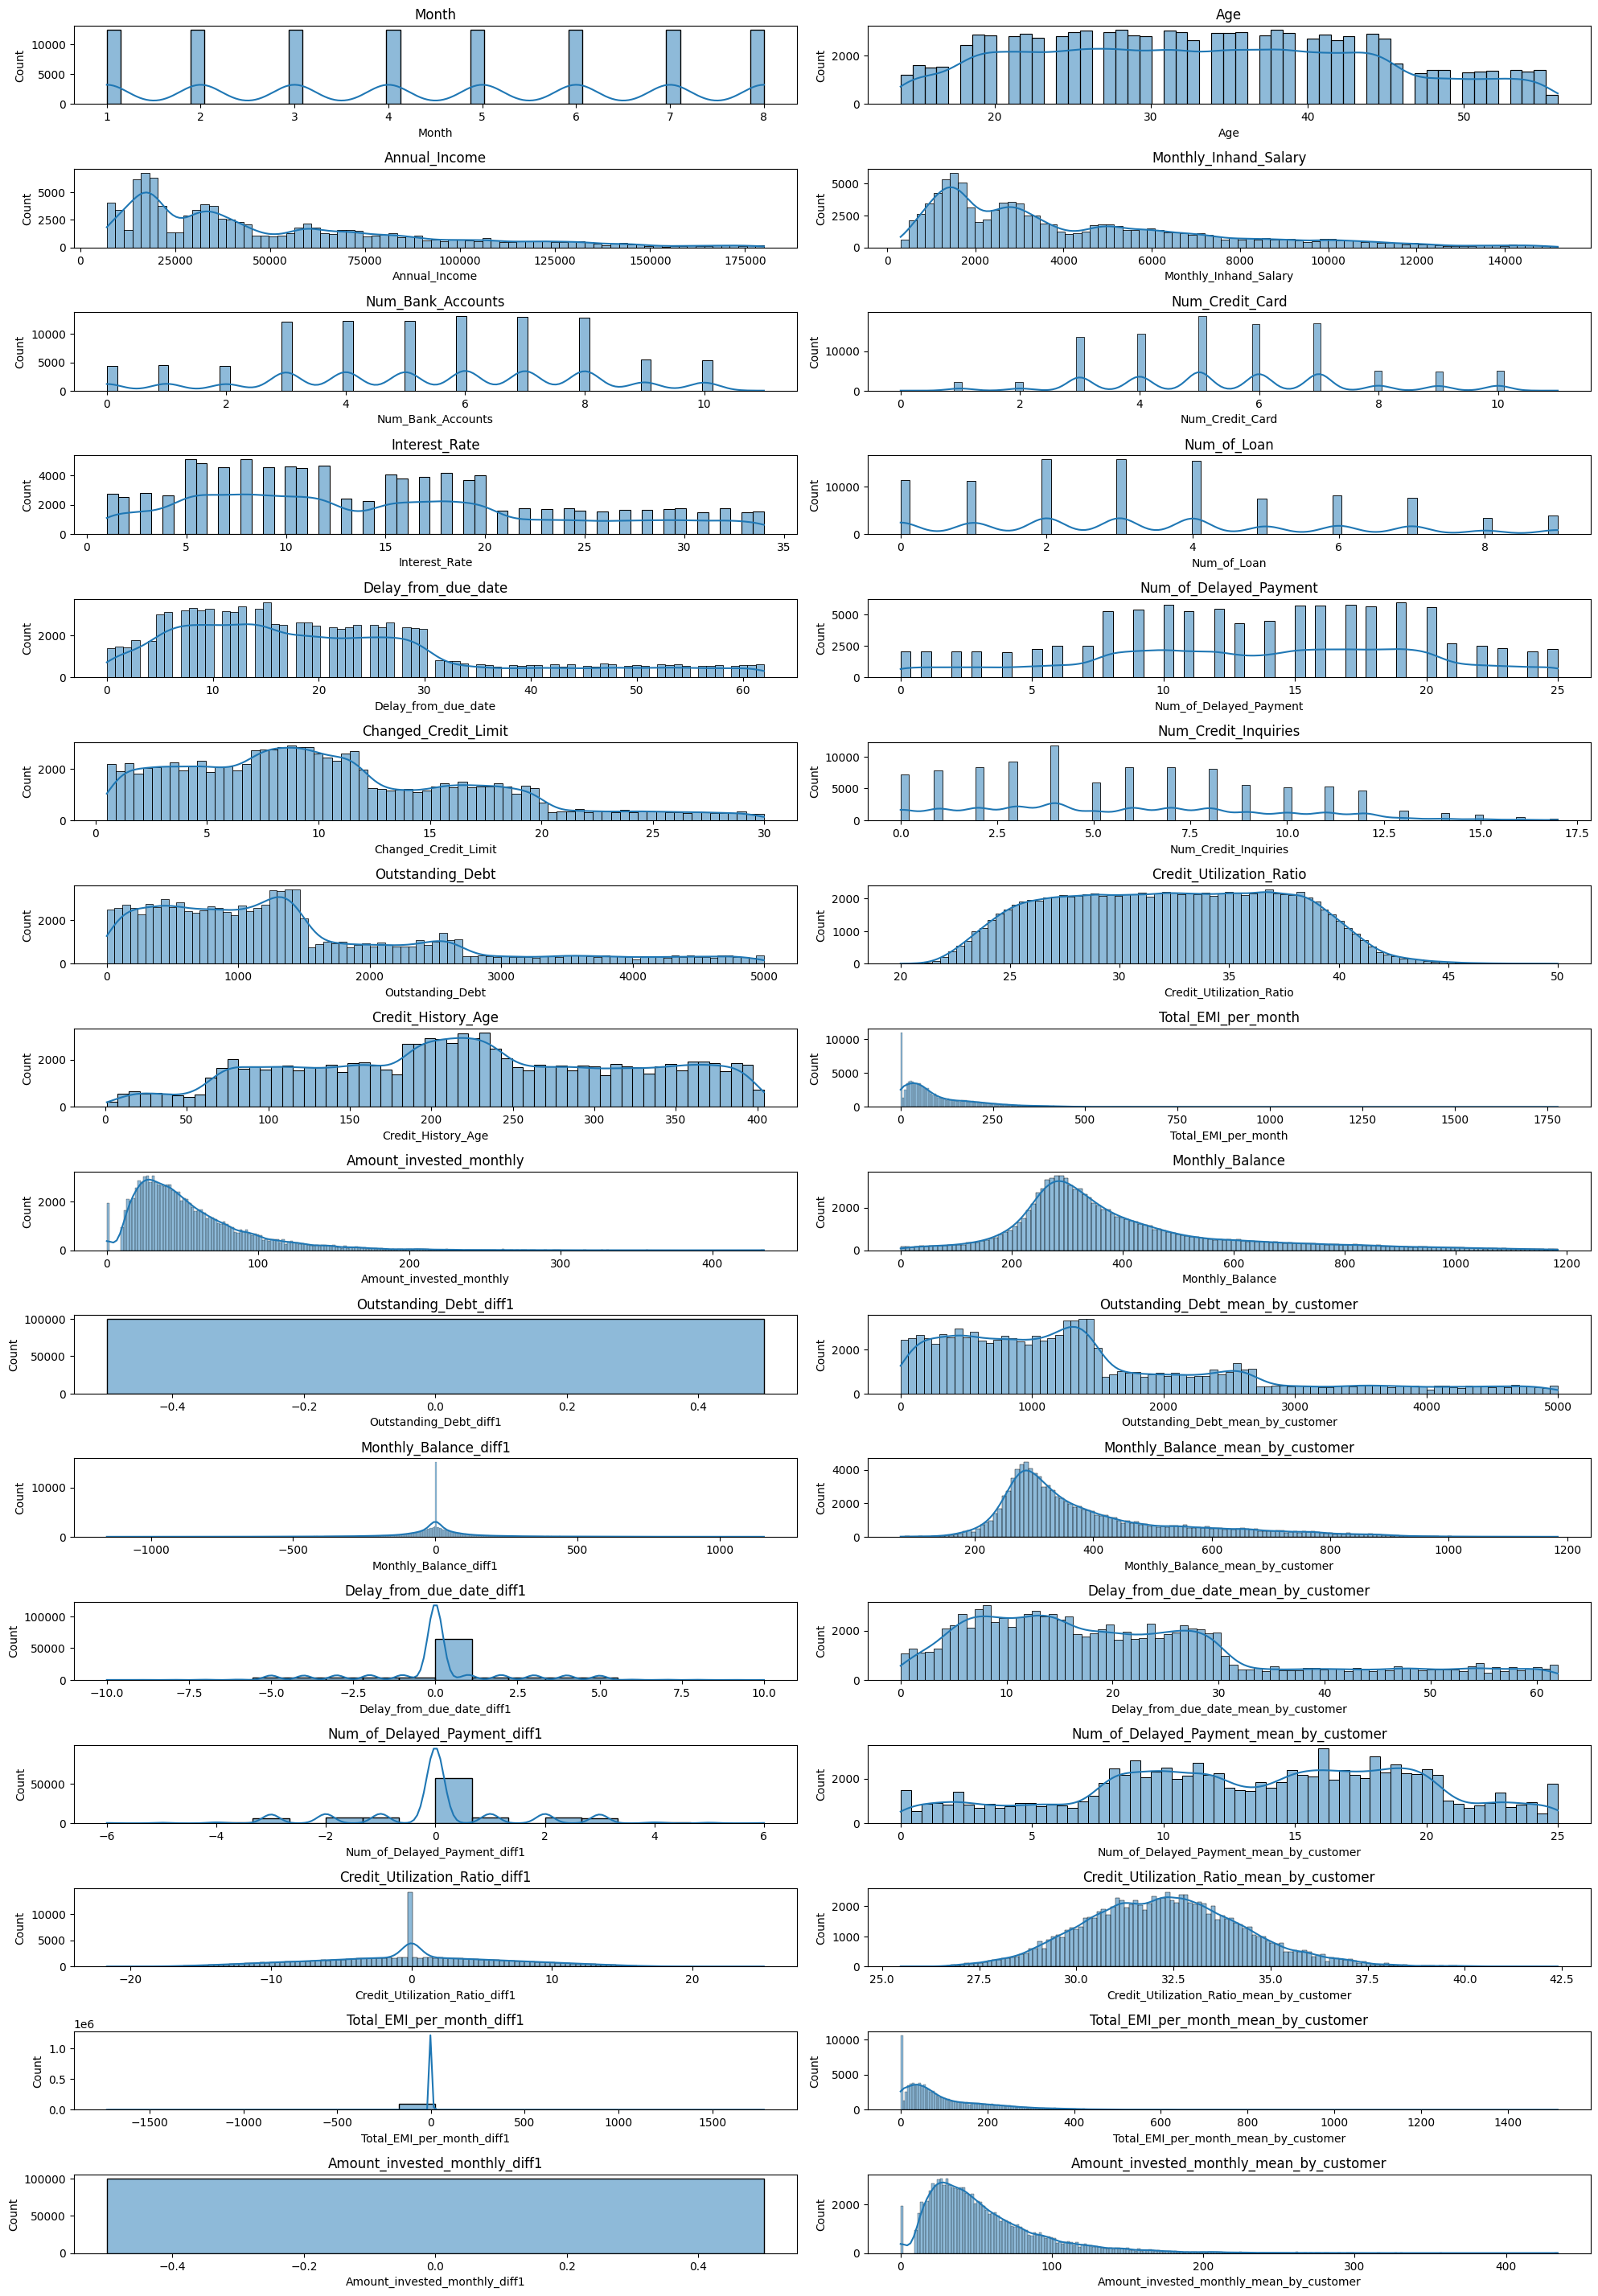

In [ ]:
plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols):

    plt.subplot(len(numeric_cols)//2 + 1, 2, i+1)

    sns.histplot(df[col], kde=True)

    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [7]:
# 무의미해 보이는 컬럼은 드랍
drop_cols = [
    'Outstanding_Debt_diff1',
    'Amount_invested_monthly_diff1'
]

df = df.drop(columns=drop_cols)

 Boxplot 및 Histogram 기반 데이터 분포 해석
  
수치형 변수에 대해 Boxplot과 Histogram을 시각화하여 이상치와 분포 형태를 확인하였다.  
  
분석 결과:  
- `Annual_Income`
- `Monthly_Inhand_Salary`
- `Outstanding_Debt`
- `Total_EMI_per_month`
- `Amount_invested_monthly`
- `Monthly_Balance`
  
등의 변수에서 우측 꼬리가 긴(right-skewed) 분포와 일부 극단값이 확인되었다.  
  
특히 `Total_EMI_per_month`와 `Amount_invested_monthly`는 소수의 고객이 매우 높은 값을 가지는 형태를 보였으며, 이는 금융 데이터 특성상 실제로 존재 가능한 고객 패턴으로 판단하였다.  
  
따라서 단순 이상치 제거보다는 정보 손실을 최소화하기 위해 로그 변환(log transformation) 및 비율 기반 파생변수 생성을 우선 고려하였다.  
  
또한 `Age`, `Num_Bank_Accounts`, `Num_Credit_Card` 등 일부 변수는 완전한 연속형 분포보다는 특정 값에 집중되는 계단형(discrete) 패턴을 보였으며, 이러한 특성을 고려하여 일부 변수는 범주형 기반 파생변수 생성 가능성을 함께 검토하였다.  
  
  
 Age 변수 처리에 대한 해석
  
Age 변수의 분포를 확인한 결과, 연속형 변수이지만 특정 연령대에 값이 집중되는 계단형(discrete) 패턴이 일부 존재하였다.    
또한 금융 데이터에서는 연령 자체보다 연령대별 금융 행동 패턴이 신용점수에 영향을 줄 가능성이 있다고 판단하였다.  
  
예를 들어:  
- 20대 초반은 신용 이력 부족 가능성
- 30~40대는 금융 활동 증가 가능성
- 50대 이상은 비교적 안정적인 금융 패턴 가능성
  
등의 특성이 존재할 수 있다.  
  
따라서 기존 Age 변수는 유지하면서, 추가적으로 연령대 기반의 Age_Group 파생변수를 생성하여 모델이 연령의 비선형적 특성을 함께 학습할 수 있도록 구성하였다.  

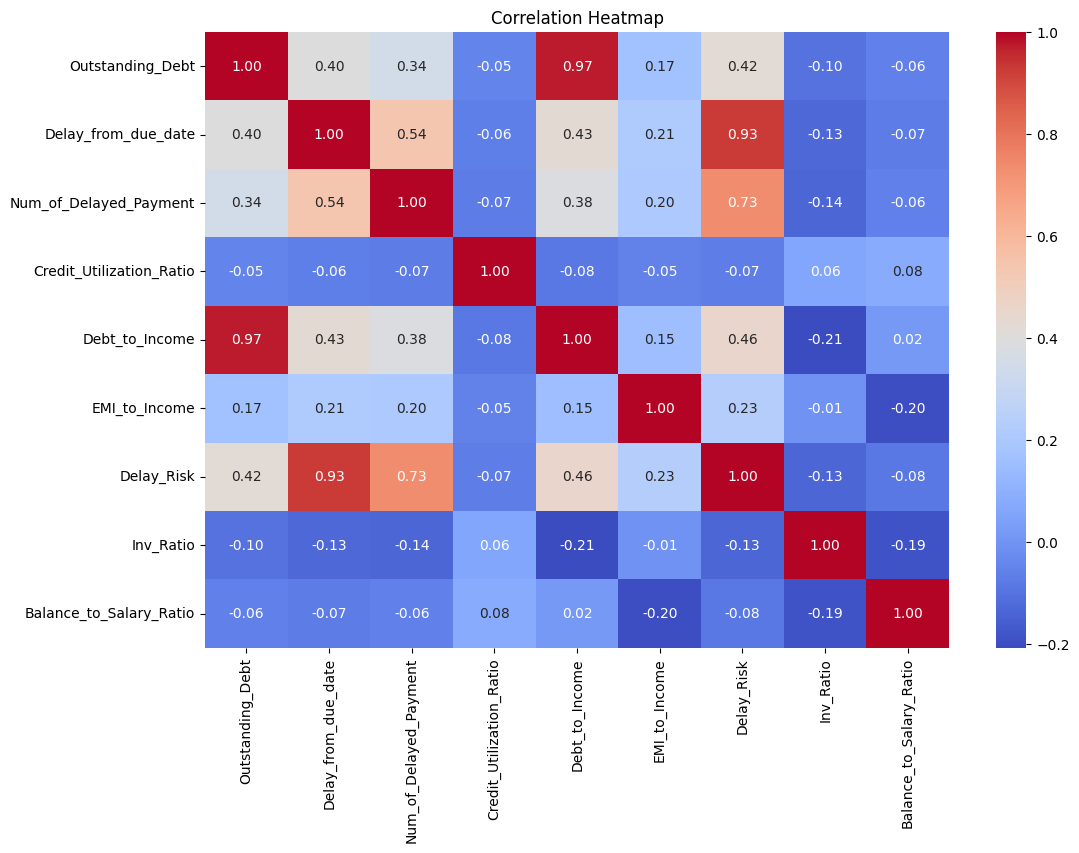

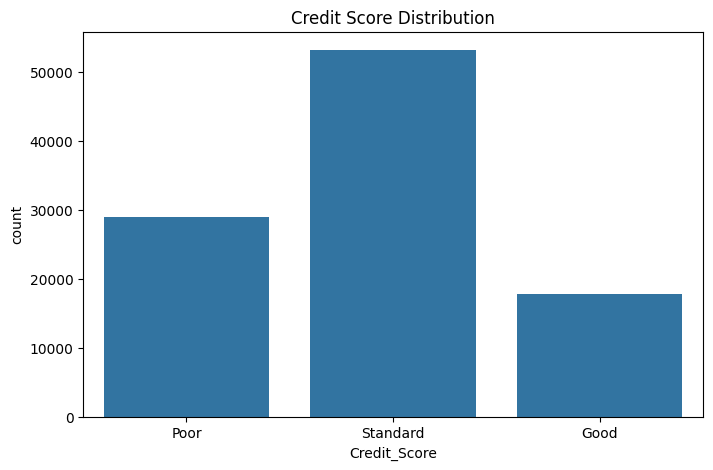

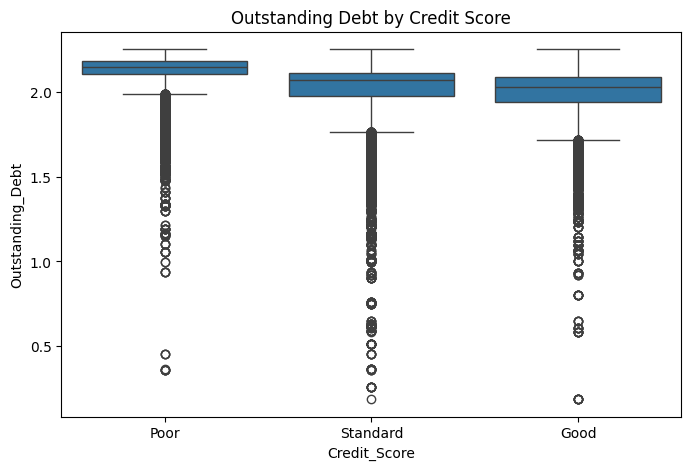

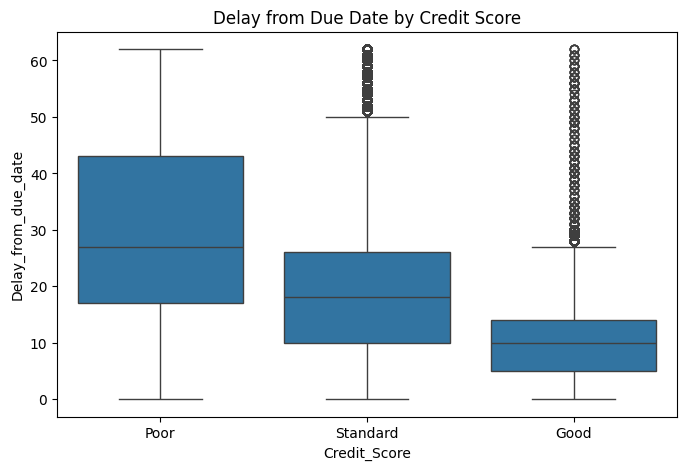

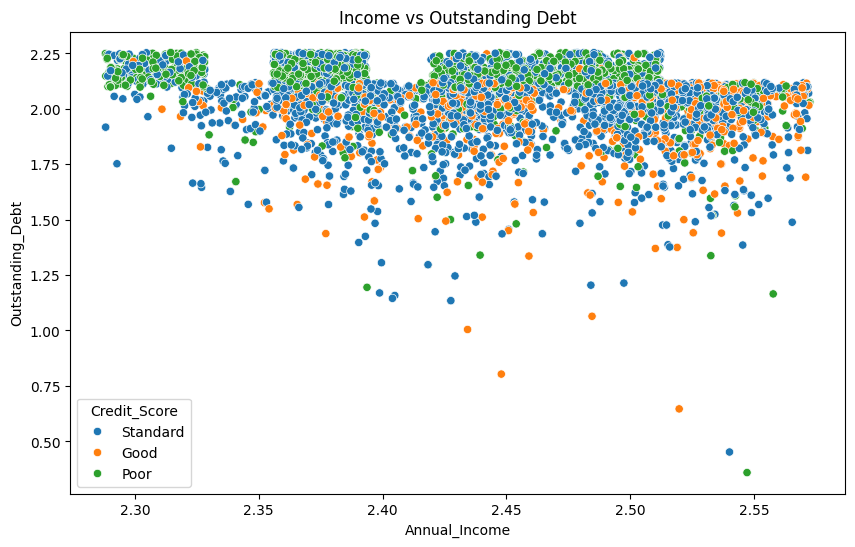

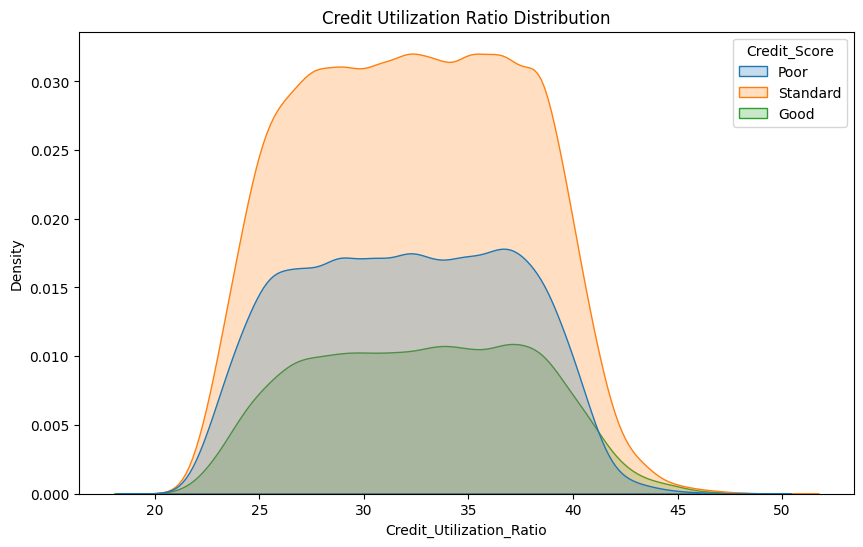

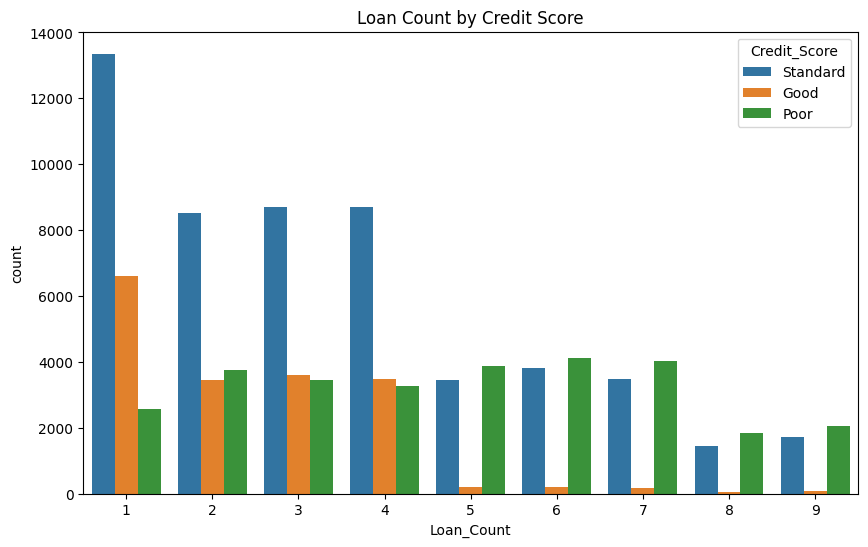

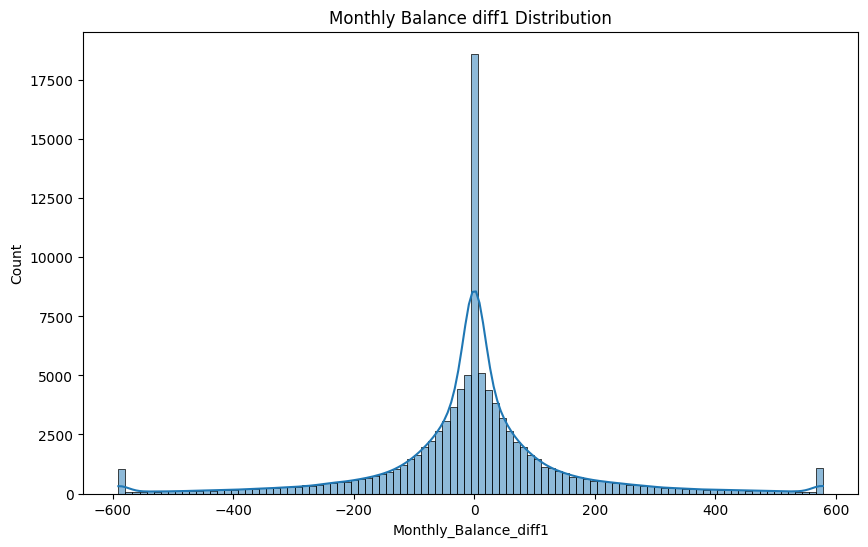

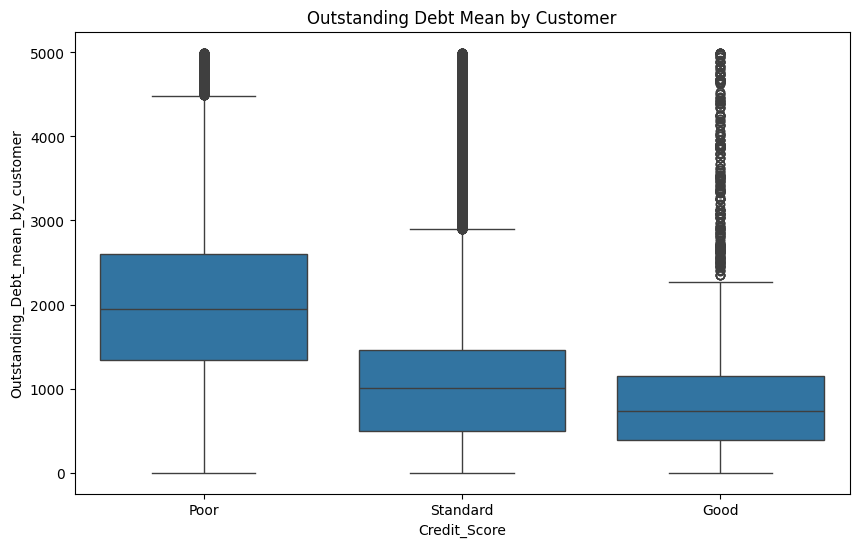

In [21]:
# 1. Correlation Heatmap


import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    'Outstanding_Debt',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Credit_Utilization_Ratio',
    'Debt_to_Income',
    'EMI_to_Income',
    'Delay_Risk',
    'Inv_Ratio',
    'Balance_to_Salary_Ratio'
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df_final[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()



# 2. Credit Score Distribution


plt.figure(figsize=(8, 5))

sns.countplot(
    x='Credit_Score',
    data=df_final
)

plt.title('Credit Score Distribution')
plt.show()




# 3. Outstanding Debt vs Credit Score


plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Credit_Score',
    y='Outstanding_Debt',
    data=df_final
)

plt.title('Outstanding Debt by Credit Score')
plt.show()




# 4. Delay_from_due_date vs Credit Score


plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Credit_Score',
    y='Delay_from_due_date',
    data=df_final
)

plt.title('Delay from Due Date by Credit Score')
plt.show()




# 5. Income vs Debt Scatter Plot


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_final.sample(5000),
    x='Annual_Income',
    y='Outstanding_Debt',
    hue='Credit_Score'
)

plt.title('Income vs Outstanding Debt')
plt.show()




# 6. Credit Utilization Ratio Distribution


plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_final,
    x='Credit_Utilization_Ratio',
    hue='Credit_Score',
    fill=True
)

plt.title('Credit Utilization Ratio Distribution')
plt.show()




# 7. Loan Count Distribution


plt.figure(figsize=(10, 6))

sns.countplot(
    x='Loan_Count',
    hue='Credit_Score',
    data=df_final
)

plt.title('Loan Count by Credit Score')
plt.show()




# 8. Monthly Balance diff1 Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    df_final['Monthly_Balance_diff1'],
    bins=100,
    kde=True
)

plt.title('Monthly Balance diff1 Distribution')
plt.show()




# 9. Outstanding Debt Mean by Customer


plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Credit_Score',
    y='Outstanding_Debt_mean_by_customer',
    data=df_final
)

plt.title('Outstanding Debt Mean by Customer')
plt.show()




# 10. Feature Importance (TabNet)


# feature_importance = pd.DataFrame({
#     'Feature': features,
#     'Importance': clf.feature_importances_
# }).sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(12, 10))

# sns.barplot(
#     x='Importance',
#     y='Feature',
#     data=feature_importance.head(20)
# )

# plt.title('Top 20 Feature Importances')
# plt.show()



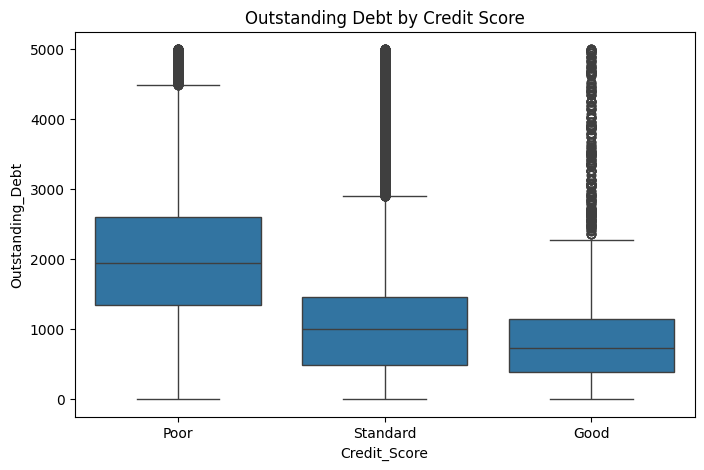

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# ================================
# Outstanding_Debt by Credit Score
# (원본값 기준 시각화)
# ================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Outstanding_Debt'
)

plt.title('Outstanding Debt by Credit Score')
plt.xlabel('Credit_Score')
plt.ylabel('Outstanding_Debt')

plt.show()


## 2. EDA를 통한 타당한 해석

EDA 결과 Poor 등급 고객일수록 Outstanding_Debt와 Delay_from_due_date의
중앙값 및 분포 범위가 상대적으로 높게 나타나는 경향을 확인하였다.

특히 단순 부채 절대값 자체보다 고객의 소득 대비 금융 부담 수준이
신용등급과 더 밀접한 관련이 있을 수 있다고 판단하였다.
이를 반영하기 위해 Debt_to_Income 파생변수를 생성하였다.

또한 연체일수와 연체횟수가 동시에 증가할 경우
신용 위험도가 더 커질 수 있다고 판단하여
Delay_Risk 변수를 추가하였다.

추가적으로 본 데이터는 동일 고객이 8개월 동안 반복 관측되는 구조를 가지므로,
단일 시점 정보만 사용하는 대신 고객별 금융 상태 변화 흐름을 반영하고자 하였다.

따라서 diff 및 mean 기반 시계열 요약 변수를 생성하여
고객의 월별 변화 패턴과 장기 평균 금융 상태를 함께 반영하였다.

# 데이터 전처리

In [7]:
# 차분값들은 clip
diff_cols = [
    col for col in df.columns
    if '_diff1' in col
]

for col in diff_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

In [9]:
# =========================
# 로그변환 후보군 지정
# =========================
# 금융 금액형 변수 중 꼬리가 길 가능성이 있는 변수들만 선택

import numpy as np

base_log_candidates = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

# 왜도 저장
skew_info = {}

# 최종 로그변환 대상
log_transform_cols = []

# =========================
# 왜도 계산
# =========================
for col in base_log_candidates:

    skew_value = df[col].skew()

    skew_info[col] = skew_value

    # 왜도가 1 이상인 경우 로그변환 대상 추가
    if skew_value > 1:
        log_transform_cols.append(col)

# =========================
# 로그변환 적용
# =========================
for col in log_transform_cols:
    df[col] = np.log1p(df[col])

# =========================
# 결과 확인
# =========================
print("=== Skewness ===")

for k, v in skew_info.items():
    print(f"{k}: {v:.4f}")

print("\n=== Log Transform Columns ===")
print(log_transform_cols)

=== Skewness ===
Annual_Income: 1.1302
Monthly_Inhand_Salary: 1.1287
Outstanding_Debt: 1.2075
Total_EMI_per_month: 4.0415
Amount_invested_monthly: 1.7610
Monthly_Balance: 1.3556

=== Log Transform Columns ===
['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


In [10]:
import numpy as np

for col in log_transform_cols:
    df[col] = np.log1p(df[col])

In [8]:
bins = [10, 25, 35, 45, 60]

labels = [
    'young',
    'early_career',
    'mid_career',
    'senior'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [12]:
df.describe()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Monthly_Balance_mean_by_customer,Delay_from_due_date_diff1,Delay_from_due_date_mean_by_customer,Num_of_Delayed_Payment_diff1,Num_of_Delayed_Payment_mean_by_customer,Credit_Utilization_Ratio_diff1,Credit_Utilization_Ratio_mean_by_customer,Total_EMI_per_month_diff1,Total_EMI_per_month_mean_by_customer,Amount_invested_monthly_mean_by_customer
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000
mean,4.500000,33.316340,2.443152,2.198292,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,...,392.697586,0.001060,21.081410,0.000590,13.31312,0.006462,32.285173,0.0,107.699208,55.101315
std,2.291299,10.764812,0.068975,0.089641,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,...,157.256911,2.108322,14.720582,1.513576,6.13808,6.565075,2.060484,0.0,119.472009,39.006932
min,1.000000,14.000000,2.287944,1.904961,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,...,74.832080,-5.000000,0.000000,-4.000000,0.00000,-14.929348,25.476634,0.0,0.000000,0.000000
25%,2.750000,24.000000,2.386019,2.127619,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,...,283.551237,0.000000,9.875000,0.000000,9.00000,-4.191624,30.854492,0.0,30.306321,27.959111
50%,4.500000,33.000000,2.443971,2.201455,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,...,336.427394,0.000000,17.875000,0.000000,13.75000,0.000000,32.241830,0.0,68.086281,45.156550
75%,6.250000,42.000000,2.499798,2.271364,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,...,457.357566,0.000000,28.000000,0.000000,18.25000,4.230786,33.600168,0.0,150.918680,71.295797
max,8.000000,56.000000,2.572662,2.363626,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,...,1183.930696,5.000000,62.000000,4.000000,25.00000,14.961448,42.395301,0.0,1515.158987,434.191089


## 범주형 전처리

In [9]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n컬럼명: {col}")
    print(f"고유값 개수: {df[col].nunique()}")
    print(df[col].unique())

# type_of_loan의 경우 고유값이 6261개임 확인결과 개인이 받은 대출의 종류이기때문에, 이는 대출 종류 개수로 변환
# 추가로 이게 ,로 이어져있어서 고유값이 6261개가 찍히는 것 같아서. ,기준으로 나눠서 unique를 찍어 특징보존을 위한 피처엔지니어링을 진행하겠


컬럼명: Occupation
고유값 개수: 15
['Journalist' 'Manager' 'Developer' 'Accountant' 'Writer' 'Mechanic'
 'Entrepreneur' 'Scientist' 'Media_Manager' 'Architect' 'Lawyer'
 'Engineer' 'Musician' 'Teacher' 'Doctor']

컬럼명: Type_of_Loan
고유값 개수: 6261
['credit-builder loan,payday loan'
 'home equity loan,mortgage loan,student loan' 'No Data' ...
 'auto loan,payday loan,student loan,payday loan'
 'home equity loan,mortgage loan,payday loan,mortgage loan,mortgage loan,payday loan'
 'student loan,credit-builder loan,mortgage loan,payday loan,home equity loan,home equity loan']

컬럼명: Credit_Mix
고유값 개수: 3
['Standard' 'Good' 'Bad']

컬럼명: Payment_of_Min_Amount
고유값 개수: 3
['Yes' 'No' 'NM']

컬럼명: Payment_Behaviour
고유값 개수: 6
['High_spent_Medium_value_payments' 'Low_spent_Medium_value_payments'
 'Low_spent_Small_value_payments' 'High_spent_Small_value_payments'
 'Low_spent_Large_value_payments' 'High_spent_Large_value_payments']

컬럼명: Credit_Score
고유값 개수: 3
['Poor' 'Standard' 'Good']


In [14]:
# Credit_Mix의 경우 순서가 유의함을 확인 (bad= 0, standard=1, good=2) -> 라벨인코딩 지정해주면 될 듯
# Payment_Behaviour의 경우 high, low / large, medium, small 이렇게 곱된 느낌임 이거 유의하게 볼 수 있을 듯 '_'기준으로 전처리해서 high,low / small,medium,large 이렇게 따로 학습할 수 있는 구조로 만들어주면 좋을 듯
# paymenr_of_min_amount 의 경우 nm의 뜻을 해석해볼 필요 있어보임 -> 확인 필요

In [10]:
# 소비 수준
df['Spent_Level'] = df['Payment_Behaviour'].apply(
    lambda x: x.split('_')[0]
)

# 결제 규모
df['Payment_Size'] = df['Payment_Behaviour'].apply(
    lambda x: x.split('_')[2]
)

df = df.drop(columns=['Payment_Behaviour'])

#### Payment_Behaviour 변수 재구성

Payment_Behaviour 변수는 소비 수준(High/Low)과 결제 규모(Small/Medium/Large)가 결합된 조합형 변수로 구성되어 있었다.

단순 Label Encoding 적용 시 각 의미가 혼합되어 정보 해석이 어려울 수 있다고 판단하였다.

따라서 소비 수준과 결제 규모를 각각 분리하여:
- Spent_Level
- Payment_Size

파생변수를 생성하였다.

이를 통해 모델이 소비 성향과 결제 패턴을 보다 독립적으로 학습할 수 있도록 구성하였다.

In [11]:
df['Type_of_Loan'].unique() # -> type 내부에 payday loan존재 -> 이는 단기 무담보 대출로, 종종 높은 이자율이 특징(https://en.wikipedia.org/wiki/Payday_loan)
                            # 이에 payday loan에 대한 유무컬럼 생성 + 종류로 변환 -> 해당변수 드랍 과정 추가.

array(['credit-builder loan,payday loan',
       'home equity loan,mortgage loan,student loan', 'No Data', ...,
       'auto loan,payday loan,student loan,payday loan',
       'home equity loan,mortgage loan,payday loan,mortgage loan,mortgage loan,payday loan',
       'student loan,credit-builder loan,mortgage loan,payday loan,home equity loan,home equity loan'],
      dtype=object)

In [12]:
all_loans = set()

for loans in df['Type_of_Loan']:
    split_loans = str(loans).split(',')

    for loan in split_loans:
        all_loans.add(loan.strip())

print(all_loans)
print(f"\n총 loan 종류 개수: {len(all_loans)}")

{'home equity loan', 'No Data', 'auto loan', 'payday loan', 'not specified', 'personal loan', 'mortgage loan', 'credit-builder loan', 'debt consolidation loan', 'student loan'}

총 loan 종류 개수: 10


#### type of loan 정리
- mortgage loan : 주택담보대출
- student loan : 학자금 대출
- payday loan : 급전 대출 느낌 :: 금융 압박 가능성 크고, 신용 위험군 가능성 큼. 단기 현금 부족의 신호
- debt consolidation loan : 부채 통합 대출 :: 이자 관리목적으로, 금융 부담이 있었을 가능성 농후 + 과거 부채 관리 이력이 존재할 가능성
- not specified : 대출종류 미기재 :: 이는 확인이 필요해보임.
- No data : 완전 비어있는 느낌이라 이것도 확인 필요
- personal loan : 개인 신용대출
- home equity loan : 주택 자산 기반 대출  (이미 집이 존재)
- credit-builder loan : 신용점수 올리기위한 대출 :: 과거 신용이 낮았거나 금융 이력이 약했을 가능성 o
- auto loan : 자동차 대출

> Type_of_Loan 변수는 6261개의 조합형 범주를 가지므로 직접 인코딩 시 희소성과 정보 손실 문제가 발생할 수 있다고 판단하였다. 따라서 개별 대출 유형을 분리하여 금융 행동 특성을 반영하고자 하였다. 특히 payday loan, debt consolidation loan 등은 금융 부담 가능성을 나타내며, mortgage loan 및 home equity loan은 자산 기반 고객 특성을 반영할 수 있다고 가정하였다.

기존 Type_of_Loan 변수는 6261개의 고유 조합을 가지며 sparsity가 심하였다.
따라서 문자열 자체를 인코딩하는 대신, 대출 종류 개수와 특정 대출 보유 여부로 재구성하여 금융 행동 특성을 보존하고자 하였다.

In [13]:
# type of loan 전처리

# =========================
# Type_of_Loan 전처리
# =========================

# loan 종류 추출
all_loans = set()

for loans in df['Type_of_Loan']:
    split_loans = str(loans).split(',')

    for loan in split_loans:
        all_loans.add(loan.strip())

print(all_loans)


# =========================
# 대출 개수 파생변수 생성
# =========================

df['Loan_Count'] = df['Type_of_Loan'].apply(
    lambda x: len(str(x).split(','))
)


# =========================
# 개별 loan binary feature 생성
# =========================

loan_types = [
    'mortgage loan',
    'student loan',
    'payday loan',
    'debt consolidation loan',
    'personal loan',
    'home equity loan',
    'credit-builder loan',
    'auto loan'
]

for loan in loan_types:

    col_name = loan.replace(' ', '_').replace('-', '_')

    df[f'has_{col_name}'] = (
        df['Type_of_Loan']
        .str.contains(loan, case=False, na=False)
        .astype(int)
    )


# =========================
# 불필요 컬럼 제거
# =========================

df = df.drop(columns=['Type_of_Loan'])


# 확인
print(display(df.head(3)))

{'home equity loan', 'No Data', 'auto loan', 'payday loan', 'not specified', 'personal loan', 'mortgage loan', 'credit-builder loan', 'debt consolidation loan', 'student loan'}


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Payment_Size,Loan_Count,has_mortgage_loan,has_student_loan,has_payday_loan,has_debt_consolidation_loan,has_personal_loan,has_home_equity_loan,has_credit_builder_loan,has_auto_loan
0,1,37,Journalist,16756.18,1331.348333,9,6,22,2,48,...,Medium,2,0,0,1,0,0,0,1,0
1,2,38,Journalist,16756.18,1331.348333,9,6,22,2,48,...,Medium,2,0,0,1,0,0,0,1,0
2,3,38,Journalist,16756.18,1331.348333,9,6,22,2,48,...,Small,2,0,0,1,0,0,0,1,0


None


## 추가 파생변수

In [14]:
# =========================
# 금융 도메인 기반 파생변수 추가
# =========================

# 1. 소득 대비 부채 비율
# 논리: 같은 부채 금액이라도 소득 수준에 따라 부담 정도가 달라짐
df['Debt_to_Income'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1)

# 2. 월급 대비 EMI 부담률
# 논리: 매달 고정적으로 상환해야 하는 금액이 월 실수령액에서 차지하는 비중
df['EMI_to_Income'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1)

# 3. 연체 위험 상호작용 지표
# 논리: 연체 일수와 연체 횟수가 동시에 클수록 신용 위험이 커질 가능성이 있음
df['Delay_Risk'] = df['Delay_from_due_date'] * df['Num_of_Delayed_Payment']


# 기존에 성능 잘 나왔던 3개도 유지
# 1. 월급 대비 투자 비중 (금융 건전성 지표)
df['Inv_Ratio'] = df['Amount_invested_monthly'] / (df['Monthly_Inhand_Salary'] + 1)

# 2. 신용 이력 대비 연체 비율 (누적 신용도 지표)
df['Delay_History_Ratio'] = df['Num_of_Delayed_Payment'] / (df['Credit_History_Age'] + 1)
# 3. 가처분 소득 대비 잔고 비율 (실질 여유자금 지표)
df['Balance_to_Salary_Ratio'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1)

#### 금융 도메인 기반 파생변수 생성

기존 변수들은 소득, 부채, 연체 횟수, 월 상환금 등 개별적인 절대값 중심으로 구성되어 있었다. 그러나 실제 신용점수는 단순한 금액의 크기보다 고객이 감당해야 하는 상대적인 금융 부담과 상환 위험에 더 큰 영향을 받을 수 있다고 판단하였다.

이에 따라 소득 대비 부채 비율, 월급 대비 EMI 부담률, 월급 대비 투자 비율, 신용 이력 대비 연체 비율, 월급 대비 잔고 비율 등을 생성하였다.

또한 연체 일수와 연체 횟수는 각각 독립적으로도 의미가 있지만, 두 값이 동시에 클수록 악성 연체 위험이 커질 수 있으므로 Delay_Risk 변수를 추가하였다.

이를 통해 모델이 단순 절대값이 아니라 고객의 실질적인 상환 부담, 금융 여유도, 연체 위험도를 함께 학습할 수 있도록 하였다.

## 1. 전처리 아이디어 적합성 + 논리

 금융 데이터 특성상 소득, 잔고, EMI 등의 금액형 변수는 우측 꼬리가 긴 분포를 보였다.
 따라서 단순 이상치 제거 대신 log1p 변환을 적용하여 왜도를 완화하였다.

 또한 Type_of_Loan 변수는 unique 값이 6000개 이상 존재하였지만,
 실제로는 여러 loan 종류 조합 형태였기 때문에 문자열 parsing을 통해
 Loan_Count 및 loan 종류별 binary feature를 생성하였다.

 Payment_Behaviour 역시 소비 수준과 결제 규모 정보가 함께 포함되어 있었기 때문에
 Spent_Level과 Payment_Size로 분리하여 각각 독립적으로 학습할 수 있도록 구성하였다.

단순 범주형 encoding보다는 금융 정보의 의미를 유지하는 방향으로 전처리를 진행하였다.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 52 columns):
 #   Column                                     Non-Null Count   Dtype   
---  ------                                     --------------   -----   
 0   Month                                      100000 non-null  int64   
 1   Age                                        100000 non-null  int64   
 2   Occupation                                 100000 non-null  object  
 3   Annual_Income                              100000 non-null  float64 
 4   Monthly_Inhand_Salary                      100000 non-null  float64 
 5   Num_Bank_Accounts                          100000 non-null  int64   
 6   Num_Credit_Card                            100000 non-null  int64   
 7   Interest_Rate                              100000 non-null  int64   
 8   Num_of_Loan                                100000 non-null  int64   
 9   Delay_from_due_date                        100000 non-null  int64   
 1

In [ ]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


# 변수 다하고 모델링

## exp1~6

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# categorical_columns = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour','Age_Group']

# for col in categorical_columns:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])

onehot_cols = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Age_Group'
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

target_encoder = LabelEncoder()
df['Credit_Score'] = target_encoder.fit_transform(df['Credit_Score'])

X = df.drop('Credit_Score', axis=1).values
y = df['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

# 속도 + 안정성 위해 batch_size 늘림
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 40

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/40], Loss: 0.7391, 학습 정확도: 65.34%, 평가 정확도: 69.25%
Epoch [2/40], Loss: 0.6879, 학습 정확도: 68.58%, 평가 정확도: 69.95%
Epoch [3/40], Loss: 0.6747, 학습 정확도: 69.11%, 평가 정확도: 70.34%
Epoch [4/40], Loss: 0.6677, 학습 정확도: 69.47%, 평가 정확도: 70.64%
Epoch [5/40], Loss: 0.6612, 학습 정확도: 69.65%, 평가 정확도: 70.72%
Epoch [6/40], Loss: 0.6574, 학습 정확도: 69.94%, 평가 정확도: 70.59%
Epoch [7/40], Loss: 0.6536, 학습 정확도: 70.16%, 평가 정확도: 70.84%
Epoch [8/40], Loss: 0.6490, 학습 정확도: 70.32%, 평가 정확도: 70.89%
Epoch [9/40], Loss: 0.6476, 학습 정확도: 70.54%, 평가 정확도: 71.02%
Epoch [10/40], Loss: 0.6444, 학습 정확도: 70.55%, 평가 정확도: 71.02%
Epoch [11/40], Loss: 0.6437, 학습 정확도: 70.53%, 평가 정확도: 71.15%
Epoch [12/40], Loss: 0.6402, 학습 정확도: 70.67%, 평가 정확도: 71.41%
Epoch [13/40], Loss: 0.6390, 학습 정확도: 70.68%, 평가 정확도: 71.36%
Epoch [14/40], Loss: 0.6365, 학습 정확도: 70.82%, 평가 정확도: 71.42%
Epoch [15/40], Loss: 0.6371, 학습 정확도: 70.82%, 평가 정확도: 71.44%
Epoch [16/40], Loss: 0.6338, 학습 정확도: 70.83%, 평가 정확도: 71.50%
Epoch [17/40], Loss: 0.6350, 학습 정확도: 70.84%, 평가 정

In [ ]:
# 탭넷
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# 1. 데이터 로드 및 전처리 (결측치 제거, 파생변수 유지)
# df = pd.read_csv('train2.csv') # 기존 파생변수 다 만든 df라고 가정!
df = df.dropna(subset=['Credit_Score'])

# 2. TabNet은 원핫 인코딩 대신 Label Encoding을 선호해!
categorical_cols = [
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'Age_Group', 'Spent_Level', 'Payment_Size'
]

# 범주형 변수들 라벨 인코딩
cat_idxs = []
cat_dims = []

for idx, col in enumerate(df.columns):
    if col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# 타겟 변수 인코딩
target_encoder = LabelEncoder()
df['Credit_Score'] = target_encoder.fit_transform(df['Credit_Score'])

# 3. 피처(X), 타겟(y) 분리
X = df.drop(columns=['Credit_Score', 'Month'], errors='ignore')
y = df['Credit_Score'].values

# 카테고리 변수 인덱스와 차원(고유값 개수) 저장 (TabNet 필수 파라미터)
features = X.columns
for idx, col in enumerate(features):
    if col in categorical_cols:
        cat_idxs.append(idx)
        cat_dims.append(len(X[col].unique()))

# 4. 수치형 변수만 스케일링
num_cols = [col for col in features if col not in categorical_cols]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# numpy 배열로 변환
X = X.values

# 5. 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. TabNet 모델 세팅 및 학습
# n_d, n_a 값을 늘리면 모델이 더 복잡한 패턴을 학습함 (보통 8~64 사이)
clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=2, # 카테고리 임베딩 차원
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)

# 7. 학습 진행 (자동으로 Early Stopping 지원됨!)
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=50,
    patience=10, # 10번 동안 성능 안 오르면 자동 종료
    batch_size=256, virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# 8. 최종 결과 확인
preds = clf.predict(X_valid)
valid_acc = np.mean(preds == y_valid) * 100
print(f"🔥 TabNet 최종 검증 정확도: {valid_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.85349 | train_accuracy: 0.64717 | valid_accuracy: 0.64075 |  0:00:25s
epoch 1  | loss: 0.73171 | train_accuracy: 0.67638 | valid_accuracy: 0.67085 |  0:00:43s
epoch 2  | loss: 0.71961 | train_accuracy: 0.65107 | valid_accuracy: 0.64995 |  0:01:01s
epoch 3  | loss: 0.71559 | train_accuracy: 0.68256 | valid_accuracy: 0.67585 |  0:01:18s
epoch 4  | loss: 0.70621 | train_accuracy: 0.69334 | valid_accuracy: 0.6904  |  0:01:36s
epoch 5  | loss: 0.694   | train_accuracy: 0.69879 | valid_accuracy: 0.69695 |  0:01:54s
epoch 6  | loss: 0.68885 | train_accuracy: 0.7011  | valid_accuracy: 0.69925 |  0:02:12s
epoch 7  | loss: 0.68354 | train_accuracy: 0.704   | valid_accuracy: 0.7029  |  0:02:30s
epoch 8  | loss: 0.67744 | train_accuracy: 0.7077  | valid_accuracy: 0.70525 |  0:02:47s
epoch 9  | loss: 0.67299 | train_accuracy: 0.71205 | valid_accuracy: 0.71095 |  0:03:05s
epoch 10 | loss: 0.66621 | train_accuracy: 0.71194 | valid_accuracy: 0.70975 |  0:03:22s
epoch 11 | loss: 0.65

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


🔥 TabNet 최종 검증 정확도: 75.90%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# 1. 범주형 변수 지정
categorical_cols = [
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'Age_Group', 'Spent_Level', 'Payment_Size'
]

cat_idxs = []
cat_dims = []

# 2. 범주형 변수 Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 3. 타겟 변수 인코딩
target_encoder = LabelEncoder()
df['Credit_Score'] = target_encoder.fit_transform(df['Credit_Score'])

# 4. 피처(X), 타겟(y) 분리
X = df.drop(columns=['Credit_Score', 'Month'], errors='ignore')
y = df['Credit_Score'].values

# 5. 카테고리 인덱스와 차원 파악
features = X.columns
for idx, col in enumerate(features):
    if col in categorical_cols:
        cat_idxs.append(idx)
        cat_dims.append(len(X[col].unique()))

# 6. 수치형 변수 스케일링 (새 변수 포함)
num_cols = [col for col in features if col not in categorical_cols]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X = X.values

# 7. 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# clf 선언부 수정: 모델을 다시 가볍게 만들고, 검증된 entmax로 복귀
clf = TabNetClassifier(
    n_d=32, n_a=32, # 다시 32로 복구 (학습 속도 및 수렴 안정화)
    n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', # 검증된 entmax로 원복! (이게 우리 데이터엔 찰떡임)
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)

# fit 부분 수정: 배치 사이즈는 1024로 다시 안정화
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=1024, # 512는 너무 널뛰어서 1024로 다시 묵직하게 가자
    virtual_batch_size=128,
)

# 10. 최종 결과 확인
preds = clf.predict(X_valid)
valid_acc = np.mean(preds == y_valid) * 100
print(f"TabNet 최종 검증 정확도: {valid_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.87973 | val_0_accuracy: 0.65325 |  0:00:09s
epoch 1  | loss: 0.73532 | val_0_accuracy: 0.6579  |  0:00:15s
epoch 2  | loss: 0.71724 | val_0_accuracy: 0.6824  |  0:00:20s
epoch 3  | loss: 0.70792 | val_0_accuracy: 0.68215 |  0:00:26s
epoch 4  | loss: 0.70444 | val_0_accuracy: 0.68665 |  0:00:31s
epoch 5  | loss: 0.70928 | val_0_accuracy: 0.6853  |  0:00:37s
epoch 6  | loss: 0.69979 | val_0_accuracy: 0.6879  |  0:00:42s
epoch 7  | loss: 0.69435 | val_0_accuracy: 0.69115 |  0:00:48s
epoch 8  | loss: 0.69404 | val_0_accuracy: 0.68945 |  0:00:53s
epoch 9  | loss: 0.69484 | val_0_accuracy: 0.6934  |  0:00:59s
epoch 10 | loss: 0.68911 | val_0_accuracy: 0.69675 |  0:01:05s
epoch 11 | loss: 0.68792 | val_0_accuracy: 0.69215 |  0:01:10s
epoch 12 | loss: 0.68834 | val_0_accuracy: 0.69645 |  0:01:16s
epoch 13 | loss: 0.68572 | val_0_accuracy: 0.69975 |  0:01:22s
epoch 14 | loss: 0.68113 | val_0_accuracy: 0.6911  |  0:01:28s
epoch 15 | loss: 0.67999 | val_0_accuracy: 0.69355 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet 최종 검증 정확도: 77.41%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# 2. 범주형 변수 지정 및 라벨 인코딩
categorical_cols = [
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'Age_Group', 'Spent_Level', 'Payment_Size'
]

cat_idxs = []
cat_dims = []

for idx, col in enumerate(df.columns):
    if col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

target_encoder = LabelEncoder()
df['Credit_Score'] = target_encoder.fit_transform(df['Credit_Score'])

# 3. 피처(X), 타겟(y) 분리
X = df.drop(columns=['Credit_Score', 'Month'], errors='ignore')
y = df['Credit_Score'].values

features = X.columns
for idx, col in enumerate(features):
    if col in categorical_cols:
        cat_idxs.append(idx)
        cat_dims.append(len(X[col].unique()))

# 4. 수치형 변수만 스케일링
num_cols = [col for col in features if col not in categorical_cols]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X = X.values

# 5. 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. [성공 세팅 복구] TabNet 모델 설정
clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, # 근본 사이즈
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5), # 근본 학습률
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', # 근본 마스크
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)

# 7. 학습 진행 (배치 사이즈도 근본인 256으로 복구)
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=100, # 혹시 모르니 에폭만 좀 더 줌
    patience=15,
    batch_size=256, virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# 8. 최종 결과 확인
preds = clf.predict(X_valid)
valid_acc = np.mean(preds == y_valid) * 100
print(f"🔥 근본 세팅 + 신규 파생변수 최종 정확도: {valid_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.81052 | train_accuracy: 0.67229 | valid_accuracy: 0.6722  |  0:00:18s
epoch 1  | loss: 0.71871 | train_accuracy: 0.68361 | valid_accuracy: 0.686   |  0:00:37s
epoch 2  | loss: 0.69189 | train_accuracy: 0.70405 | valid_accuracy: 0.7012  |  0:00:56s
epoch 3  | loss: 0.67975 | train_accuracy: 0.7092  | valid_accuracy: 0.7061  |  0:01:15s
epoch 4  | loss: 0.67658 | train_accuracy: 0.7087  | valid_accuracy: 0.70685 |  0:01:34s
epoch 5  | loss: 0.67323 | train_accuracy: 0.71139 | valid_accuracy: 0.7058  |  0:01:53s
epoch 6  | loss: 0.67335 | train_accuracy: 0.71335 | valid_accuracy: 0.71155 |  0:02:12s
epoch 7  | loss: 0.66566 | train_accuracy: 0.71368 | valid_accuracy: 0.7086  |  0:02:30s
epoch 8  | loss: 0.66191 | train_accuracy: 0.71631 | valid_accuracy: 0.71005 |  0:02:49s
epoch 9  | loss: 0.65853 | train_accuracy: 0.71576 | valid_accuracy: 0.70985 |  0:03:08s
epoch 10 | loss: 0.65376 | train_accuracy: 0.71855 | valid_accuracy: 0.71095 |  0:03:27s
epoch 11 | loss: 0.65

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


🔥 근본 세팅 + 신규 파생변수 최종 정확도: 78.50%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 평가 모드로 예측값 생성 (내부적으로 eval 모드 작동)
preds = clf.predict(X_valid)

# 2. 상세 분류 리포트 출력 (정확도, 정밀도, 재현율 등)
# 이거 출력 결과를 리포트에 복붙하면 '설명의 깊이'에서 가산점 받음!
print("✨ [최종 모델 검증 리포트]")
print(classification_report(y_valid, preds, target_names=target_encoder.classes_))

# 3. Feature Importance 시각화 (평가 기준 3번용)
# 모델이 어떤 변수를 보고 '신용'을 판단했는지 보여주는 핵심 근거
importance = clf.feature_importances_
feat_importances = pd.Series(importance, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features (TabNet)")
plt.xlabel("Importance Score")
plt.show()

# 4. 검증 점수 딱 하나만 깔끔하게 출력 (평가 기준 5번)
valid_acc = (preds == y_valid).mean() * 100
print(f"✅ Final Validation Accuracy: {valid_acc:.2f}%")



#### 데이터 분할 방식

Credit_Score 클래스 분포를 확인한 결과 Standard 클래스 비율이 가장 높고, Good 클래스 비율은 상대적으로 낮은 불균형 특성이 존재하였다.

따라서 train/test 분할 시 클래스 비율 왜곡을 최소화하기 위해 stratify 옵션을 적용하여 데이터 분포를 유지하였다.

## 1차 tabnet

In [ ]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from pytorch_tabnet.tab_model import TabNetClassifier

# =========================
# 0. 데이터 복사
# =========================
data = df.copy()

# =========================
# 1. 결측치 처리
# =========================
#data = data.fillna(0)

# =========================
# 2. 범주형 컬럼 지정
# =========================
categorical_cols = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Age_Group',
    'Spent_Level',
    'Payment_Size'
]

# =========================
# 3. 범주형 Label Encoding
# =========================
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# =========================
# 4. Target Encoding
# =========================
target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'].astype(str))

# =========================
# 5. diff 변수 clipping
# =========================
diff_cols = [col for col in data.columns if '_diff1' in col]

for col in diff_cols:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data[col] = data[col].clip(lower, upper)

# =========================
# 6. X, y 분리
# =========================
X = data.drop(columns=['Credit_Score'], errors='ignore')
y = data['Credit_Score'].values

features = X.columns.tolist()

# =========================
# 7. cat_idxs, cat_dims 설정
# =========================
cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols:
        cat_idxs.append(idx)
        cat_dims.append(X[col].nunique())

print("cat_idxs:", cat_idxs)
print("cat_dims:", cat_dims)

# =========================
# 8. 수치형만 Scaling
# =========================
num_cols = [col for col in features if col not in categorical_cols]

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X = X.values.astype(np.float32)

# =========================
# 9. Train / Valid split
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 10. TabNet 모델
# =========================
clf = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,

    n_independent=2,
    n_shared=2,

    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=2,

    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.NAdam,
    optimizer_params=dict(
        lr=1e-2,
        weight_decay=1e-5
    ),

    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={
        "step_size": 10,
        "gamma": 0.9
    },

    mask_type='entmax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    seed=42
)

# =========================
# 11. 학습
# =========================
clf.fit(
    X_train=X_train,
    y_train=y_train,

    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],

    max_epochs=100,
    patience=15,

    batch_size=256,
    virtual_batch_size=128,

    num_workers=0,
    drop_last=False
)

# =========================
# 12. 평가
# =========================
preds = clf.predict(X_valid)
valid_acc = accuracy_score(y_valid, preds) * 100

print(f"TabNet Validation Accuracy: {valid_acc:.2f}%")

cat_idxs: [2, 13, 17, 33, 34, 35]
cat_dims: [15, 3, 3, 4, 2, 3]


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.83685 | train_accuracy: 0.65516 | valid_accuracy: 0.65765 |  0:00:20s
epoch 1  | loss: 0.72102 | train_accuracy: 0.67856 | valid_accuracy: 0.68365 |  0:00:41s
epoch 2  | loss: 0.68443 | train_accuracy: 0.69802 | valid_accuracy: 0.70175 |  0:00:59s
epoch 3  | loss: 0.67125 | train_accuracy: 0.69632 | valid_accuracy: 0.69855 |  0:01:18s
epoch 4  | loss: 0.66541 | train_accuracy: 0.70415 | valid_accuracy: 0.7065  |  0:01:36s
epoch 5  | loss: 0.65552 | train_accuracy: 0.70824 | valid_accuracy: 0.7111  |  0:01:55s
epoch 6  | loss: 0.65077 | train_accuracy: 0.70982 | valid_accuracy: 0.71275 |  0:02:15s
epoch 7  | loss: 0.64447 | train_accuracy: 0.71482 | valid_accuracy: 0.71445 |  0:02:34s
epoch 8  | loss: 0.63846 | train_accuracy: 0.71591 | valid_accuracy: 0.7171  |  0:02:52s
epoch 9  | loss: 0.63278 | train_accuracy: 0.71219 | valid_accuracy: 0.71075 |  0:03:11s
epoch 10 | loss: 0.62769 | train_accuracy: 0.72131 | valid_accuracy: 0.7195  |  0:03:30s
epoch 11 | loss: 0.62

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Validation Accuracy: 82.79%


In [ ]:
# == 오버피팅 방지 추가 피처 셀렉션

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': clf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.round(2))

                                      Feature  Importance
0                                       Month        0.14
13                                 Credit_Mix        0.12
7                               Interest_Rate        0.09
21          Outstanding_Debt_mean_by_customer        0.07
26               Num_of_Delayed_Payment_diff1        0.05
17                      Payment_of_Min_Amount        0.05
9                         Delay_from_due_date        0.05
6                             Num_Credit_Card        0.04
25       Delay_from_due_date_mean_by_customer        0.04
12                       Num_Credit_Inquiries        0.03
35                               Payment_Size        0.03
23           Monthly_Balance_mean_by_customer        0.03
16                         Credit_History_Age        0.02
27    Num_of_Delayed_Payment_mean_by_customer        0.02
45                             Debt_to_Income        0.02
46                              EMI_to_Income        0.02
20            

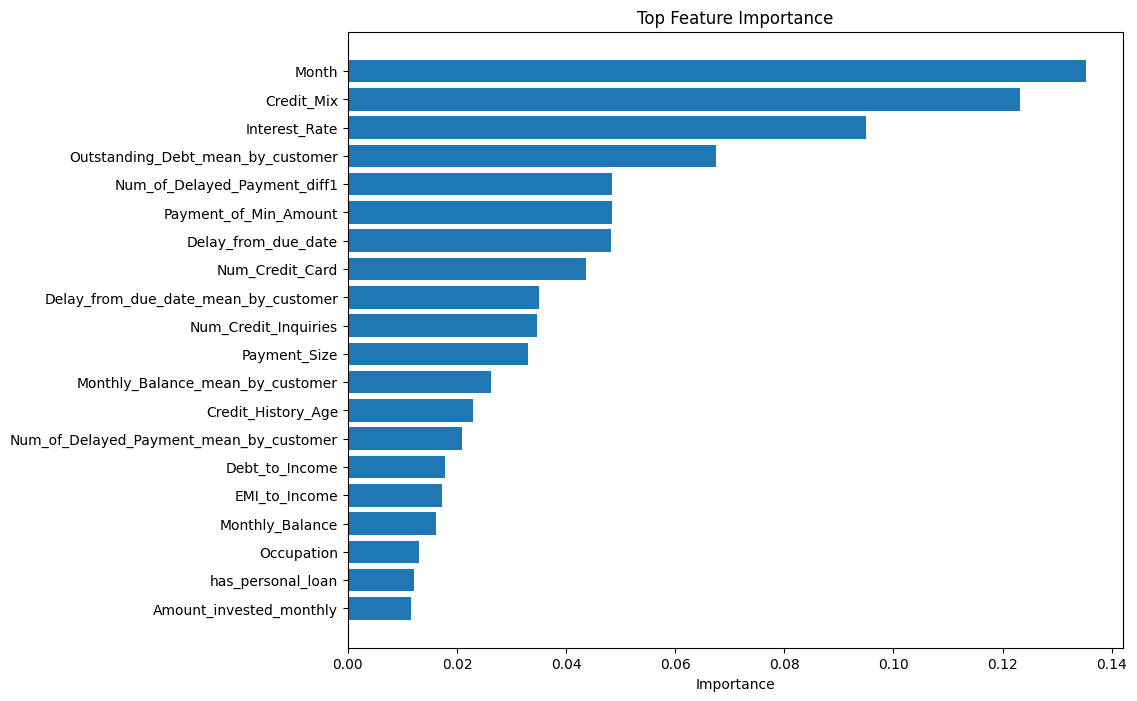

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'][:top_n][::-1],
    feature_importance['Importance'][:top_n][::-1]
)

plt.title('Top Feature Importance')
plt.xlabel('Importance')

plt.show()

TabNet feature importance 분석 결과, 단순 현재 상태 변수보다 고객별 평균 금융 상태(mean)와 연체 변화량(diff) 관련 변수가 높은 중요도를 가지는 것을 확인하였다.

특히 Outstanding_Debt_mean_by_customer, Delay 관련 시계열 요약 변수들이 상위권에 위치하여 고객의 장기적인 금융 패턴이 신용점수 예측에 중요한 영향을 미치는 것으로 해석할 수 있었다.

## tabnet - feture importance 기반 selection (<0.003)

In [ ]:
# =========================
# 1. Feature Importance DataFrame 생성
# =========================
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# =========================
# 2. 중요도 낮은 변수 확인
# =========================
low_importance_features = feature_importance[
    feature_importance['Importance'] < 0.003
]['Feature'].tolist()

print("제거 후보 변수:")
print(low_importance_features)
print("제거 후보 개수:", len(low_importance_features))

                                      Feature    Importance
0                                       Month  1.352817e-01
13                                 Credit_Mix  1.232459e-01
7                               Interest_Rate  9.499292e-02
21          Outstanding_Debt_mean_by_customer  6.756748e-02
26               Num_of_Delayed_Payment_diff1  4.839419e-02
17                      Payment_of_Min_Amount  4.835700e-02
9                         Delay_from_due_date  4.815521e-02
6                             Num_Credit_Card  4.372368e-02
25       Delay_from_due_date_mean_by_customer  3.504537e-02
12                       Num_Credit_Inquiries  3.464984e-02
35                               Payment_Size  3.305591e-02
23           Monthly_Balance_mean_by_customer  2.626425e-02
16                         Credit_History_Age  2.289173e-02
27    Num_of_Delayed_Payment_mean_by_customer  2.084462e-02
45                             Debt_to_Income  1.781131e-02
46                              EMI_to_I

In [ ]:
# =========================
# 3. 낮은 중요도 변수 제거
# =========================
data_fs = data.drop(columns=low_importance_features, errors='ignore')

print("기존 feature 수:", len(features))
print("제거 후 feature 수:", data_fs.drop(columns=['Credit_Score']).shape[1])

기존 feature 수: 51
제거 후 feature 수: 38


In [ ]:
categorical_cols_fs = [
    col for col in categorical_cols
    if col in data_fs.columns
]

In [ ]:
categorical_cols_fs = [
    col for col in categorical_cols
    if col in data_fs.columns
]
X = data_fs.drop(columns=['Credit_Score'], errors='ignore')
y = data_fs['Credit_Score'].values

features = X.columns.tolist()

cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols_fs:
        cat_idxs.append(idx)
        cat_dims.append(X[col].nunique())

num_cols = [col for col in features if col not in categorical_cols_fs]

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X = X.values.astype(np.float32)

In [ ]:
# =========================
# 1. Train / Valid Split
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 2. Feature Selection 이후 TabNet 모델
# =========================
clf_fs = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,

    n_independent=2,
    n_shared=2,

    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=2,

    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.NAdam,
    optimizer_params=dict(
        lr=1e-2,
        weight_decay=1e-5
    ),

    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={
        "step_size": 10,
        "gamma": 0.9
    },

    mask_type='entmax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    seed=42
)

# =========================
# 3. 학습
# =========================
clf_fs.fit(
    X_train=X_train,
    y_train=y_train,

    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],

    max_epochs=100,
    patience=15,

    batch_size=256,
    virtual_batch_size=128,

    num_workers=0,
    drop_last=False
)

# =========================
# 4. 평가
# =========================
preds = clf_fs.predict(X_valid)

valid_acc = np.mean(preds == y_valid)

print(f"Feature Selection 적용 Accuracy: {valid_acc:.5f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.82988 | train_accuracy: 0.641   | valid_accuracy: 0.64355 |  0:00:22s
epoch 1  | loss: 0.71456 | train_accuracy: 0.66639 | valid_accuracy: 0.66625 |  0:00:42s
epoch 2  | loss: 0.68475 | train_accuracy: 0.68799 | valid_accuracy: 0.69035 |  0:01:01s
epoch 3  | loss: 0.67594 | train_accuracy: 0.6877  | valid_accuracy: 0.68895 |  0:01:20s
epoch 4  | loss: 0.66975 | train_accuracy: 0.68434 | valid_accuracy: 0.68395 |  0:01:39s
epoch 5  | loss: 0.66648 | train_accuracy: 0.68664 | valid_accuracy: 0.69085 |  0:01:58s
epoch 6  | loss: 0.66506 | train_accuracy: 0.68944 | valid_accuracy: 0.68915 |  0:02:17s
epoch 7  | loss: 0.66049 | train_accuracy: 0.69026 | valid_accuracy: 0.69245 |  0:02:36s
epoch 8  | loss: 0.65939 | train_accuracy: 0.68506 | valid_accuracy: 0.68805 |  0:02:55s
epoch 9  | loss: 0.6548  | train_accuracy: 0.69681 | valid_accuracy: 0.69705 |  0:03:14s
epoch 10 | loss: 0.65282 | train_accuracy: 0.69064 | valid_accuracy: 0.6922  |  0:03:34s
epoch 11 | loss: 0.64

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Feature Selection 적용 Accuracy: 0.81460


Feature Importance 기반 변수 제거를 시도하였으나, 중요도가 낮아 보이는 변수들도 TabNet 내부의 feature interaction에서 일부 기여할 가능성이 있었다. 따라서 과도한 변수 제거는 성능 저하로 이어질 수 있다고 판단하였다.

## mlp튜닝

In [ ]:
# mlp
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================
# 1. 범주형 변수 Label Encoding
# =====================================================

categorical_columns = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Age_Group',
    'Spent_Level',
    'Payment_Size'
]

df_mlp = df.copy()

for col in categorical_columns:

    le = LabelEncoder()

    df_mlp[col] = le.fit_transform(
        df_mlp[col].astype(str)
    )

# target encoding
target_encoder = LabelEncoder()

df_mlp['Credit_Score'] = target_encoder.fit_transform(
    df_mlp['Credit_Score']
)

# =====================================================
# 2. X / y 분리
# =====================================================

X = df_mlp.drop(
    columns=['Credit_Score'],
    errors='ignore'
).values

y = df_mlp['Credit_Score'].values

# =====================================================
# 3. Standard Scaling
# =====================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# =====================================================
# 4. train / test split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. Dataset 정의
# =====================================================

class CreditDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# dataset 생성
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

# dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

# =====================================================
# 6. Deep MLP 모델 정의
# =====================================================

class DeepMLP(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            # block 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            # block 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            # block 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            # block 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            # output
            nn.Linear(64, 3)
        )

    def forward(self, x):

        return self.network(x)

# =====================================================
# 7. device 설정
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 모델 생성
input_size = X_train.shape[1]

model = DeepMLP(input_size).to(device)

# =====================================================
# 8. Loss / Optimizer / Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss()

# NAdam optimizer
optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

# learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

# =====================================================
# 9. 학습
# =====================================================

epochs = 100

for epoch in range(epochs):

    # -------------------------
    # train
    # -------------------------
    model.train()

    running_loss = 0.0

    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += targets.size(0)

        correct_train += (
            predicted == targets
        ).sum().item()

    # -------------------------
    # validation
    # -------------------------
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for inputs, targets in test_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            total_val += targets.size(0)

            correct_val += (
                predicted == targets
            ).sum().item()

    # accuracy 계산
    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val

    # scheduler step
    scheduler.step(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Valid Acc: {val_accuracy:.2f}%"
    )

Epoch [1/100] | Loss: 0.7295 | Train Acc: 66.20% | Valid Acc: 70.27%
Epoch [2/100] | Loss: 0.6759 | Train Acc: 69.07% | Valid Acc: 70.83%
Epoch [3/100] | Loss: 0.6609 | Train Acc: 69.83% | Valid Acc: 71.17%
Epoch [4/100] | Loss: 0.6540 | Train Acc: 70.25% | Valid Acc: 71.46%
Epoch [5/100] | Loss: 0.6468 | Train Acc: 70.34% | Valid Acc: 71.56%
Epoch [6/100] | Loss: 0.6411 | Train Acc: 70.75% | Valid Acc: 71.77%
Epoch [7/100] | Loss: 0.6374 | Train Acc: 70.93% | Valid Acc: 71.91%
Epoch [8/100] | Loss: 0.6320 | Train Acc: 71.28% | Valid Acc: 71.81%
Epoch [9/100] | Loss: 0.6270 | Train Acc: 71.38% | Valid Acc: 72.10%
Epoch [10/100] | Loss: 0.6245 | Train Acc: 71.54% | Valid Acc: 72.18%
Epoch [11/100] | Loss: 0.6205 | Train Acc: 71.78% | Valid Acc: 72.41%
Epoch [12/100] | Loss: 0.6165 | Train Acc: 71.89% | Valid Acc: 72.12%
Epoch [13/100] | Loss: 0.6128 | Train Acc: 71.92% | Valid Acc: 72.67%
Epoch [14/100] | Loss: 0.6090 | Train Acc: 72.27% | Valid Acc: 72.58%
Epoch [15/100] | Loss: 0.6062

## mlp epoch 추가실험. (과적합도 아니게 보이고, 더 올라갈 것 같아서.)


In [ ]:
# mlp epoch 추가실험. (과적합도 아니게 보이고, 더 올라갈 것 같아서.)
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================
# 1. 범주형 변수 Label Encoding
# =====================================================

categorical_columns = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Age_Group',
    'Spent_Level',
    'Payment_Size'
]

df_mlp = df.copy()

for col in categorical_columns:

    le = LabelEncoder()

    df_mlp[col] = le.fit_transform(
        df_mlp[col].astype(str)
    )

# target encoding
target_encoder = LabelEncoder()

df_mlp['Credit_Score'] = target_encoder.fit_transform(
    df_mlp['Credit_Score']
)

# =====================================================
# 2. X / y 분리
# =====================================================

X = df_mlp.drop(
    columns=['Credit_Score'],
    errors='ignore'
).values

y = df_mlp['Credit_Score'].values

# =====================================================
# 3. Standard Scaling
# =====================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# =====================================================
# 4. train / test split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. Dataset 정의
# =====================================================

class CreditDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# dataset 생성
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

# dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

# =====================================================
# 6. Deep MLP 모델 정의
# =====================================================

class DeepMLP(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            # block 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            # block 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            # block 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            # block 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            # output
            nn.Linear(64, 3)
        )

    def forward(self, x):

        return self.network(x)

# =====================================================
# 7. device 설정
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 모델 생성
input_size = X_train.shape[1]

model = DeepMLP(input_size).to(device)

# =====================================================
# 8. Loss / Optimizer / Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss()

# NAdam optimizer
optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

# learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

# =====================================================
# 9. 학습
# =====================================================

epochs = 150
patience = 10

best_val_acc = 0.0
best_epoch = 0
early_stop_count = 0

for epoch in range(epochs):

    # -------------------------
    # train
    # -------------------------
    model.train()

    running_loss = 0.0

    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += targets.size(0)

        correct_train += (
            predicted == targets
        ).sum().item()

    # -------------------------
    # validation
    # -------------------------
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for inputs, targets in test_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            total_val += targets.size(0)

            correct_val += (
                predicted == targets
            ).sum().item()

    # accuracy 계산
    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val

    # =========================
    # best score 저장
    # =========================
    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy
        best_epoch = epoch + 1

        early_stop_count = 0

        # best 모델 저장
        best_model_state = model.state_dict()

    else:

        early_stop_count += 1

    # scheduler step
    scheduler.step(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Valid Acc: {val_accuracy:.2f}% | "
        f"Best: {best_val_acc:.2f}% at Epoch {best_epoch}"
    )

    # =========================
    # early stopping
    # =========================
    if early_stop_count >= patience:

        print(f"\nEarly Stopping at Epoch {epoch+1}")

        break

Epoch [1/150] | Loss: 0.7267 | Train Acc: 66.50% | Valid Acc: 70.42% | Best: 70.42% at Epoch 1
Epoch [2/150] | Loss: 0.6758 | Train Acc: 69.26% | Valid Acc: 70.83% | Best: 70.83% at Epoch 2
Epoch [3/150] | Loss: 0.6608 | Train Acc: 69.82% | Valid Acc: 70.99% | Best: 70.99% at Epoch 3
Epoch [4/150] | Loss: 0.6524 | Train Acc: 70.30% | Valid Acc: 71.45% | Best: 71.45% at Epoch 4
Epoch [5/150] | Loss: 0.6454 | Train Acc: 70.52% | Valid Acc: 71.62% | Best: 71.62% at Epoch 5
Epoch [6/150] | Loss: 0.6414 | Train Acc: 70.67% | Valid Acc: 71.72% | Best: 71.72% at Epoch 6
Epoch [7/150] | Loss: 0.6365 | Train Acc: 71.07% | Valid Acc: 71.84% | Best: 71.84% at Epoch 7
Epoch [8/150] | Loss: 0.6322 | Train Acc: 71.13% | Valid Acc: 71.85% | Best: 71.85% at Epoch 8
Epoch [9/150] | Loss: 0.6279 | Train Acc: 71.48% | Valid Acc: 72.06% | Best: 72.06% at Epoch 9
Epoch [10/150] | Loss: 0.6238 | Train Acc: 71.53% | Valid Acc: 72.08% | Best: 72.08% at Epoch 10
Epoch [11/150] | Loss: 0.6189 | Train Acc: 71.80

## 마지막 tabnet 튜닝

In [ ]:
# 마지막 tabnet 튜닝
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from pytorch_tabnet.tab_model import TabNetClassifier

# =========================
# 0. 데이터 복사
# =========================
data = df.copy()

# =========================
# 1. 범주형 컬럼
# =========================
categorical_cols = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Age_Group',
    'Spent_Level',
    'Payment_Size'
]

# =========================
# 2. 범주형 Label Encoding
# =========================
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# target encoding
target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(
    data['Credit_Score'].astype(str)
)

# =========================
# 3. diff 변수 clipping
# =========================
diff_cols = [col for col in data.columns if '_diff1' in col]

for col in diff_cols:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data[col] = data[col].clip(lower, upper)

# =========================
# 4. X / y 분리
# =========================
X = data.drop(columns=['Credit_Score'], errors='ignore')
y = data['Credit_Score'].values

features = X.columns.tolist()

# =========================
# 5. TabNet categorical 설정
# =========================
cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols:
        cat_idxs.append(idx)
        cat_dims.append(X[col].nunique())

print("cat_idxs:", cat_idxs)
print("cat_dims:", cat_dims)

# =========================
# 6. 수치형만 Scaling
# =========================
num_cols = [col for col in features if col not in categorical_cols]

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X = X.values.astype(np.float32)

# =========================
# 7. Train / Valid Split
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 8. Tuned TabNet
# =========================
clf_final = TabNetClassifier(
    # 표현력 증가
    n_d=64,
    n_a=64,
    n_steps=5,

    gamma=1.5,
    n_independent=2,
    n_shared=2,

    # categorical embedding 강화
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=4,

    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.NAdam,
    optimizer_params=dict(
        lr=1e-2,
        weight_decay=1e-5
    ),

    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={
        "step_size": 10,
        "gamma": 0.9
    },

    mask_type='entmax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    seed=42
)

# =========================
# 9. 학습
# =========================
clf_final.fit(
    X_train=X_train,
    y_train=y_train,

    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],

    max_epochs=150,
    patience=15,

    batch_size=256,
    virtual_batch_size=128,

    num_workers=0,
    drop_last=False
)

# =========================
# 10. 평가
# =========================
preds = clf_final.predict(X_valid)
valid_acc = accuracy_score(y_valid, preds)

print(f"Final Tuned TabNet Accuracy: {valid_acc:.5f}")

cat_idxs: [2, 13, 17, 33, 34, 35]
cat_dims: [15, 3, 3, 4, 2, 3]


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.88621 | train_accuracy: 0.66182 | valid_accuracy: 0.6619  |  0:00:26s
epoch 1  | loss: 0.70151 | train_accuracy: 0.68682 | valid_accuracy: 0.6887  |  0:00:53s
epoch 2  | loss: 0.67326 | train_accuracy: 0.69991 | valid_accuracy: 0.70575 |  0:01:15s
epoch 3  | loss: 0.65502 | train_accuracy: 0.70888 | valid_accuracy: 0.71325 |  0:01:44s
epoch 4  | loss: 0.6451  | train_accuracy: 0.7109  | valid_accuracy: 0.7128  |  0:02:22s
epoch 5  | loss: 0.63801 | train_accuracy: 0.71718 | valid_accuracy: 0.7164  |  0:02:43s
epoch 6  | loss: 0.63372 | train_accuracy: 0.71846 | valid_accuracy: 0.71695 |  0:03:06s
epoch 7  | loss: 0.63116 | train_accuracy: 0.7112  | valid_accuracy: 0.70995 |  0:03:33s
epoch 8  | loss: 0.62531 | train_accuracy: 0.72361 | valid_accuracy: 0.7225  |  0:03:54s
epoch 9  | loss: 0.61445 | train_accuracy: 0.72705 | valid_accuracy: 0.71955 |  0:04:14s
epoch 10 | loss: 0.60448 | train_accuracy: 0.73382 | valid_accuracy: 0.72865 |  0:04:35s
epoch 11 | loss: 0.59

KeyboardInterrupt: 

In [ ]:
# 오히려 과적합같은느낌 있어서 stop
#TabNet의 표현력을 높이기 위해 n_d, n_a 및 categorical embedding dimension을 확장한 추가 튜닝을 수행하였다. 그러나 학습 정확도는 빠르게 상승한 반면 validation accuracy는 81% 수준에서 정체되어 과적합 가능성이 확인되었다. 이에 따라 최종 모델은 validation 성능과 일반화 안정성이 더 우수했던 Deep MLP로 선정하였다.

## 마지막 파생변수 추가 mlp

In [15]:
# =========================
# 마지막 추가 파생변수 (최종 4개)
# =========================

df_final = df.copy()

# 1. 월 소비 추정치
# 월급 - EMI - 투자 - 잔고
df_final['Estimated_Spending'] = (
    df_final['Monthly_Inhand_Salary']
    - df_final['Total_EMI_per_month']
    - df_final['Amount_invested_monthly']
    - df_final['Monthly_Balance']
)

# 2. 월급 대비 소비 비율
df_final['Spending_to_Income'] = (
    df_final['Estimated_Spending']
    / (df_final['Monthly_Inhand_Salary'] + 1)
)

# 3. 신용조회 / 신용이력 비율
df_final['Inquiry_to_History'] = (
    df_final['Num_Credit_Inquiries']
    / (df_final['Credit_History_Age'] + 1)
)

# 4. 이자율 × 부채 위험
df_final['Interest_Debt_Risk'] = (
    df_final['Interest_Rate']
    * df_final['Outstanding_Debt']
)

# inf 처리
# df_final = df_final.replace([np.inf, -np.inf], 0)
# df_final = df_final.fillna(0)

In [ ]:
# =====================================================
# 마지막 변수 추가 + Deep MLP 최종 실험
# =====================================================

import copy
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# =====================================================
# 1. 범주형 변수 Label Encoding
# =====================================================

categorical_columns = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Age_Group',
    'Spent_Level',
    'Payment_Size'
]

df_mlp = df_final.copy()

for col in categorical_columns:
    le = LabelEncoder()
    df_mlp[col] = le.fit_transform(df_mlp[col].astype(str))

# target encoding
target_encoder = LabelEncoder()
df_mlp['Credit_Score'] = target_encoder.fit_transform(
    df_mlp['Credit_Score'].astype(str)
)

# =====================================================
# 2. X / y 분리
# =====================================================

X = df_mlp.drop(
    columns=['Credit_Score'],
    errors='ignore'
).values

y = df_mlp['Credit_Score'].values

# =====================================================
# 3. Standard Scaling
# =====================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# =====================================================
# 4. train / valid split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. Dataset 정의
# =====================================================

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CreditDataset(X_train, y_train)
valid_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=256,
    shuffle=False
)

# =====================================================
# 6. Deep MLP 모델 정의
# =====================================================

class DeepMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# =====================================================
# 7. Device / Model
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X_train.shape[1]
model = DeepMLP(input_size).to(device)

# =====================================================
# 8. Loss / Optimizer / Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

# =====================================================
# 9. Train
# =====================================================

epochs = 150
patience = 10

best_val_acc = 0.0
best_epoch = 0
early_stop_count = 0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):

    # -------------------------
    # train
    # -------------------------
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    # -------------------------
    # validation
    # -------------------------
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in valid_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    # accuracy 계산
    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val

    # best score 저장
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        early_stop_count = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        early_stop_count += 1

    # scheduler step
    scheduler.step(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Valid Acc: {val_accuracy:.2f}% | "
        f"Best: {best_val_acc:.2f}% at Epoch {best_epoch}"
    )

    # early stopping
    if early_stop_count >= patience:
        print(f"\nEarly Stopping at Epoch {epoch+1}")
        break

# =====================================================
# 10. Best Model Load / Final Score
# =====================================================

model.load_state_dict(best_model_state)

print("=" * 60)
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Best Epoch: {best_epoch}")
print("=" * 60)

Epoch [1/150] | Loss: 0.7288 | Train Acc: 66.30% | Valid Acc: 70.58% | Best: 70.58% at Epoch 1
Epoch [2/150] | Loss: 0.6735 | Train Acc: 69.31% | Valid Acc: 71.20% | Best: 71.20% at Epoch 2
Epoch [3/150] | Loss: 0.6582 | Train Acc: 69.87% | Valid Acc: 71.44% | Best: 71.44% at Epoch 3
Epoch [4/150] | Loss: 0.6516 | Train Acc: 70.23% | Valid Acc: 71.28% | Best: 71.44% at Epoch 3
Epoch [5/150] | Loss: 0.6450 | Train Acc: 70.55% | Valid Acc: 71.38% | Best: 71.44% at Epoch 3
Epoch [6/150] | Loss: 0.6404 | Train Acc: 70.72% | Valid Acc: 71.84% | Best: 71.84% at Epoch 6
Epoch [7/150] | Loss: 0.6360 | Train Acc: 70.83% | Valid Acc: 71.85% | Best: 71.85% at Epoch 7
Epoch [8/150] | Loss: 0.6316 | Train Acc: 71.12% | Valid Acc: 72.08% | Best: 72.08% at Epoch 8
Epoch [9/150] | Loss: 0.6276 | Train Acc: 71.31% | Valid Acc: 71.94% | Best: 72.08% at Epoch 8
Epoch [10/150] | Loss: 0.6246 | Train Acc: 71.31% | Valid Acc: 72.48% | Best: 72.48% at Epoch 10
Epoch [11/150] | Loss: 0.6207 | Train Acc: 71.64

초기에는 TabNet 기반 접근이 더 효과적일 것으로 예상하였으나, 금융 도메인 기반 Feature Engineering과 고객별 시계열 요약 변수를 추가하면서 Deep MLP 또한 매우 높은 성능을 보였다.

이는 Tabular 데이터에서 Feature Representation 자체가 모델 성능에 큰 영향을 미친다는 점을 보여주며, 충분한 Feature Engineering이 수행된 경우 비교적 단순한 Dense 구조 또한 강력한 성능을 낼 수 있음을 확인하였다.

# 최종정리

## 수정된 실험 결과 테이블

## Experiment Results

| 실험       | 전처리 / Feature Engineering                                     | 모델        | Accuracy  |
| -------- | ------------------------------------------------------------- | --------- | --------- |
| Baseline | 기본 전처리 (Label Encoding + Standard Scaling)                    | MLP       | 71.0      |
| Exp1     | 로그 변환 + Type_of_Loan Parsing + Loan Count / Loan Flag 생성      | MLP       | 72.45     |
| Exp2     | Age_Group 파생변수 추가                                             | MLP       | 72.35     |
| Exp3     | BatchNorm, Dropout, Hidden Layer 확장 등 MLP 구조 개선               | MLP+      | 72.60     |
| Exp4     | 기존 전처리 기반 TabNet 적용                                           | TabNet    | 71.0      |
| Exp5     | Payment_Behaviour 분해 + 금융 파생변수 일부 추가 + Optimizer/Scheduler 조정 | MLP+      | 71.3      |
| Exp6     | 범주형 변수 Label Encoding 후 TabNet categorical embedding 적용       | TabNet+   | 75.9      |
| Exp7     | 금융 비율 기반 파생변수 추가 + TabNet 하이퍼파라미터 튜닝                          | TabNet++  | 77.41     |
| Exp8     | 금융 ratio 파생변수 최적화 + 기존 최고 성능 TabNet 세팅 적용                     | TabNet    | 78.5      |
| Exp9     | 고객별 월별 시계열 요약 변수(diff, mean) 추가                               | TabNet++  | 82.79     |
| Exp10    | Feature Importance 기반 Feature Selection 및 변수 정제 (<0.003)      | TabNet ++ | 81.46     |
| Exp11    | 기존 feature 유지 + Deep MLP 튜닝 + Early Stopping                  | MLP++     | 83.14     |
| Exp12    | 추가 현금흐름 / 신용조회 / 이자위험 파생변수 적용 + Deep MLP                      | MLP ++ | **83.36** |


# 3. Feature Selection과 모델 선택, 튜닝 기준

초기에는 기본 MLP 모델을 사용하였으며 Accuracy는 약 71% 수준이었다.

이후 BatchNorm, Dropout, Hidden Layer 확장, NAdam Optimizer, ReduceLROnPlateau 등을 적용하여 모델의 일반화 성능을 개선하고자 하였다.

또한 범주형 변수가 많은 금융 데이터 특성을 고려하여 categorical embedding을 지원하는 TabNet 모델도 함께 실험하였다.

Feature Selection은 TabNet Feature Importance를 기반으로 진행하였다. 다만 일부 변수 제거 이후 오히려 성능이 감소하는 현상이 발생하였다.

이를 통해 단일 변수 중요도뿐 아니라 변수 간 interaction 역시 중요한 영향을 미친다고 판단하였다.

최종적으로는 feature를 유지한 상태에서 Deep MLP를 추가 튜닝하였으며, 가장 높은 Validation Accuracy를 기록한 모델을 최종 모델로 선정하였다.

# 4. 개선사항

현재 프로젝트에서는 고객별 diff 및 mean 기반 시계열 요약 변수까지 반영하였지만,
rolling mean, rolling std, 최근 3개월 변화량 등
보다 세밀한 시계열 패턴까지는 반영하지 못하였다.

따라서 추가적인 시계열 feature를 활용할 경우
고객의 금융 상태 변화 흐름을 더 효과적으로 반영할 수 있을 것으로 예상된다.

또한 TabNet 외에도 FT-Transformer, TabTransformer, NODE 등
다양한 Tabular Deep Learning 모델을 추가적으로 비교해볼 필요가 있다.

Feature Engineering 측면에서는
금융 소비 패턴, 고위험 대출 조합, 신용조회 패턴 등을 반영한
추가 금융 도메인 기반 변수 생성도 가능할 것으로 보인다.

마지막으로 현재는 Accuracy 중심으로 모델을 평가하였지만,
실제 금융 환경에서는 F1-score, Recall 등
리스크 관점의 평가 지표도 함께 고려할 필요가 있다.

# 5. validation score 출력

 최종 모델은 금융 도메인 기반 파생변수와
 고객별 월별 패턴 변수(diff, mean)를 반영한 Deep MLP 모델이다.

 최종 Validation Accuracy는 0.8336을 기록하였다.

 특히 금융 ratio 변수와 고객별 시계열 요약 변수 추가 이후
 가장 큰 성능 향상을 확인할 수 있었다.